In [1]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def read_tensorboard_scalar(log_dir, tag="Accuracy"):
    """Liest die X- und Y-Werte einer bestimmten Kurve aus."""
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()
    
    if tag in event_acc.Tags().get('scalars', []):
        events = event_acc.Scalars(tag)
        steps = [e.step for e in events]
        vals = [e.value for e in events]
        return steps, vals
    else:
        print(f"⚠️ Warnung: Kurve '{tag}' in '{log_dir}' nicht gefunden.")
        return [], []

def plot_learning_rates(lr_dict, model_name="Modell"):
    """Plottet Train und Val für verschiedene Learning Rates in einem Graphen."""
    plt.figure(figsize=(10, 6))
    
    # 3 farbenblinden-freundliche, deutliche Farben für die 3 Learning Rates
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"] # Blau, Orange, Grün
    
    # Wir iterieren durch dein Dictionary (unten definiert)
    for i, (lr_label, lr_base_path) in enumerate(lr_dict.items()):
        color = colors[i % len(colors)]
        
        # Pfade zu den Unterordnern bauen
        path_train = os.path.join(lr_base_path, "Accuracy_train")
        path_val = os.path.join(lr_base_path, "Accuracy_val")
        
        # Daten auslesen
        steps_train, vals_train = read_tensorboard_scalar(path_train, tag="Accuracy")
        steps_val, vals_val = read_tensorboard_scalar(path_val, tag="Accuracy")
        
        # 1. Training plotten (Gestrichelt, etwas dünner)
        if steps_train and vals_train:
            plt.plot(steps_train, vals_train, color=color, linestyle="--", 
                     alpha=0.6, linewidth=1.5, label=f"Train ({lr_label})")
            
        # 2. Validierung plotten (Durchgezogen, fett - da am wichtigsten!)
        if steps_val and vals_val:
            plt.plot(steps_val, vals_val, color=color, linestyle="-", 
                     alpha=0.9, linewidth=2.5, label=f"Val ({lr_label})")

    # --- Paper-Ready Styling ---
    plt.title(f"Einfluss der Learning Rate auf das Training ({model_name})", fontsize=14, pad=15)
    plt.xlabel("Epoche", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    
    plt.grid(True, linestyle=":", alpha=0.7, color="gray")
    
    # Legende außerhalb oder gut platziert
    plt.legend(fontsize=11, loc="lower right", framealpha=0.9)
    
    plt.tight_layout()
    
    # Als Vektorgrafik speichern
    dateiname = f"LR_Vergleich_{model_name}.pdf"
    #plt.savefig(dateiname, format="pdf", bbox_inches="tight")
    #print(f"\n✅ Plot erfolgreich als '{dateiname}' gespeichert!")
    
    plt.show()

# ==========================================
# HIER DEINE PFADE EINTRAGEN
# ==========================================
# Ein Dictionary: Der Text in den Anführungszeichen wird der Name in der Legende,
# dahinter kommt der Pfad zu genau diesem Run.
meine_lr_runs = {
    f"lr = 1e-3": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_grid_08_01_01_new/DM_time_binary_classificator_241002_9_GAP_-ft_100_15/lr0.001_wd0.0001",
    f"lr = 1e-4": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_grid_08_01_01_new/DM_time_binary_classificator_241002_9_GAP_-ft_100_15/lr0.0001_wd0.0001",
    f"lr = 1e-5": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_grid_08_01_01_new/DM_time_binary_classificator_241002_9_GAP_-ft_100_15/lr1e-05_wd0.0001"
}

plot_learning_rates(meine_lr_runs, model_name="9_GAP")

DirectoryDeletedError: Directory /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_grid_08_01_01_new/DM_time_binary_classificator_241002_9_GAP_-ft_100_15/lr0.001_wd0.0001/Accuracy_train has been permanently deleted

<Figure size 1000x600 with 0 Axes>

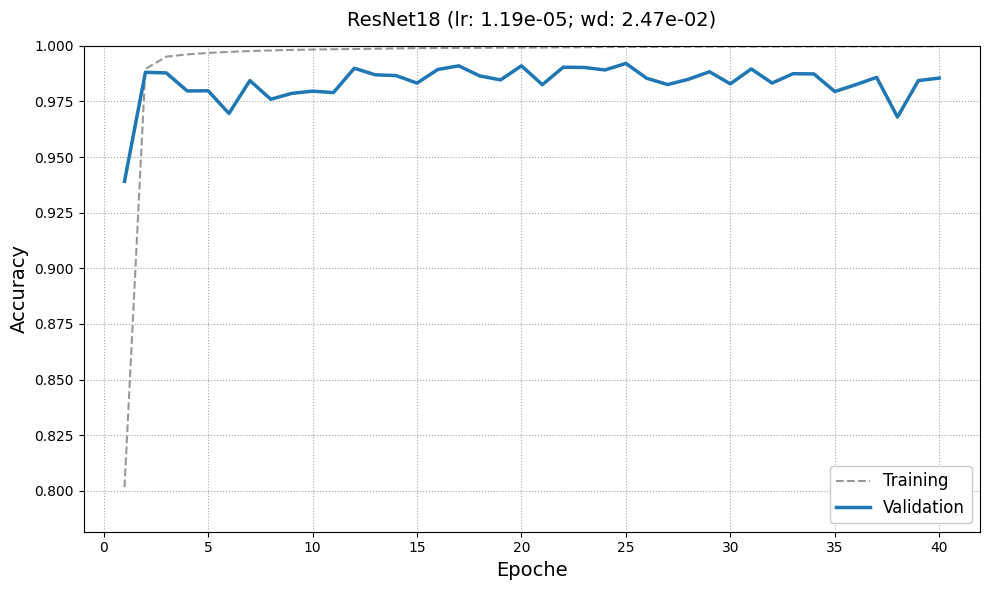

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def read_tensorboard_scalar(log_dir, tag="Accuracy"):
    """Liest die X- und Y-Werte einer bestimmten Kurve aus."""
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()
    
    if tag in event_acc.Tags().get('scalars', []):
        events = event_acc.Scalars(tag)
        steps = [e.step for e in events]
        vals = [e.value for e in events]
        return steps, vals
    else:
        print(f"⚠️ Warnung: Kurve '{tag}' in '{log_dir}' nicht gefunden.")
        return [], []

def plot_single_run(run_path, model_name):
    """Plottet Train und Val für einen einzelnen Run in Paper-Qualität."""
    plt.figure(figsize=(10, 6))
    
    # Pfade zu den Unterordnern bauen
    path_train = os.path.join(run_path, "Accuracy_train")
    path_val = os.path.join(run_path, "Accuracy_val")
    
    # Daten auslesen
    steps_train, vals_train = read_tensorboard_scalar(path_train, tag="Accuracy")
    steps_val, vals_val = read_tensorboard_scalar(path_val, tag="Accuracy")
    
    # Kontrastreiche Farben: Grau für Training, kräftiges Blau für Validation
    color_train = "#7f7f7f"
    color_val = "#1f77b4"
    
    # Minimum-Wert suchen, um die Y-Achse dynamisch anzupassen
    min_val = min(min(vals_train) if vals_train else 1.0, 
                  min(vals_val) if vals_val else 1.0)
    
    # 1. Training plotten (Gestrichelt)
    if steps_train and vals_train:
        plt.plot(steps_train, vals_train, color=color_train, linestyle="--", 
                 alpha=0.8, linewidth=1.5, label="Training")
        
    # 2. Validierung plotten (Durchgezogen, fett)
    if steps_val and vals_val:
        plt.plot(steps_val, vals_val, color=color_val, linestyle="-", 
                 alpha=1.0, linewidth=2.5, label="Validation")

    # --- Paper-Ready Styling ---
    # TITEL ENTFERNT! (Wird im LaTeX via \caption gemacht)
    plt.title(f"{model_name}", fontsize=14, pad=15)
    plt.xlabel("Epoche", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)
    
    # X-Achse: Nur ganze Zahlen! (Keine 2.5 Epochen mehr)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Y-Achse: Etwas unter dem echten Minimum starten, oben starr bei 1.0
    y_bottom = max(0.0, min_val - 0.02) # Puffer nach unten
    plt.ylim(y_bottom, 1.0)
    
    plt.grid(True, linestyle=":", alpha=0.7, color="gray")
    
    # Legende
    plt.legend(fontsize=12, loc="lower right", framealpha=1.0)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# AUSFÜHRUNG
# ==========================================
run_path = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.3-dmft_Container0/lr3.09e-05_wd1.90e-03"

# Funktion aufrufen (Dateiname ohne '.pdf' Endung übergeben)
plot_single_run(run_path, model_name="ResNet18 (lr: 1.19e-05; wd: 2.47e-02)")

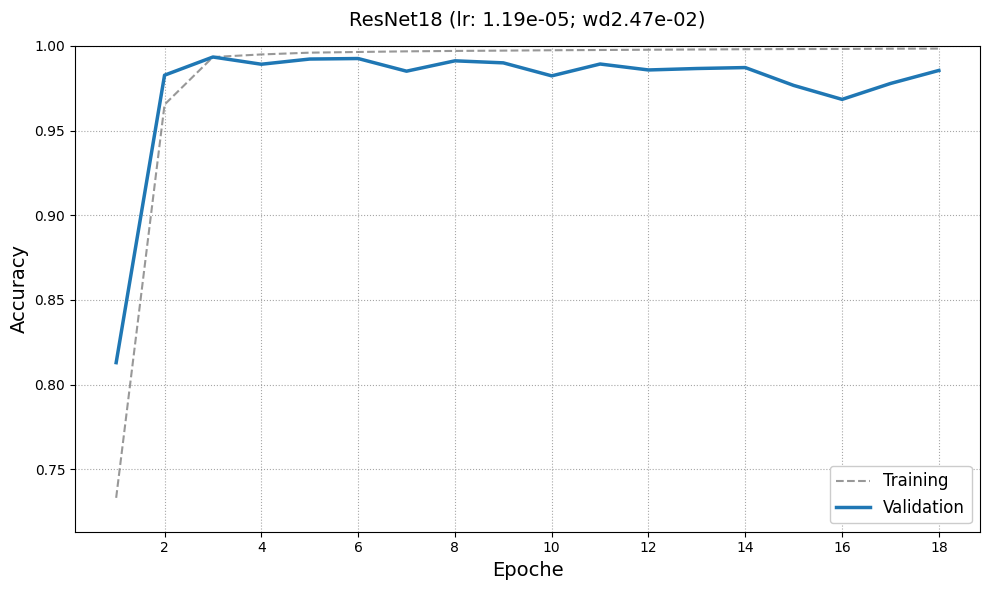

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def read_tensorboard_scalar(log_dir, tag="Accuracy"):
    """Liest die X- und Y-Werte einer bestimmten Kurve aus."""
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()
    
    if tag in event_acc.Tags().get('scalars', []):
        events = event_acc.Scalars(tag)
        steps = [e.step for e in events]
        vals = [e.value for e in events]
        return steps, vals
    else:
        print(f"⚠️ Warnung: Kurve '{tag}' in '{log_dir}' nicht gefunden.")
        return [], []

def plot_single_run(run_path, model_name):
    """Plottet Train und Val für einen einzelnen Run in Paper-Qualität."""
    plt.figure(figsize=(10, 6))
    
    # Pfade zu den Unterordnern bauen
    path_train = os.path.join(run_path, "Accuracy_train")
    path_val = os.path.join(run_path, "Accuracy_val")
    
    # Daten auslesen
    steps_train, vals_train = read_tensorboard_scalar(path_train, tag="Accuracy")
    steps_val, vals_val = read_tensorboard_scalar(path_val, tag="Accuracy")
    
    # Kontrastreiche Farben: Grau für Training, kräftiges Blau für Validation
    color_train = "#7f7f7f"
    color_val = "#1f77b4"
    
    # Minimum-Wert suchen, um die Y-Achse dynamisch anzupassen
    min_val = min(min(vals_train) if vals_train else 1.0, 
                  min(vals_val) if vals_val else 1.0)
    
    # 1. Training plotten (Gestrichelt)
    if steps_train and vals_train:
        plt.plot(steps_train, vals_train, color=color_train, linestyle="--", 
                 alpha=0.8, linewidth=1.5, label="Training")
        
    # 2. Validierung plotten (Durchgezogen, fett)
    if steps_val and vals_val:
        plt.plot(steps_val, vals_val, color=color_val, linestyle="-", 
                 alpha=1.0, linewidth=2.5, label="Validation")

    # --- Paper-Ready Styling ---
    # TITEL ENTFERNT! (Wird im LaTeX via \caption gemacht)
    plt.title(f"{model_name}", fontsize=14, pad=15)
    plt.xlabel("Epoche", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)
    
    # X-Achse: Nur ganze Zahlen! (Keine 2.5 Epochen mehr)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Y-Achse: Etwas unter dem echten Minimum starten, oben starr bei 1.0
    y_bottom = max(0.0, min_val - 0.02) # Puffer nach unten
    plt.ylim(y_bottom, 1.0)
    
    plt.grid(True, linestyle=":", alpha=0.7, color="gray")
    
    # Legende
    plt.legend(fontsize=12, loc="lower right", framealpha=1.0)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# AUSFÜHRUNG
# ==========================================
run_path = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.3-dmft_Container1/lr1.19e-05_wd2.47e-02"

# Funktion aufrufen (Dateiname ohne '.pdf' Endung übergeben)
plot_single_run(run_path, model_name="ResNet18 (lr: 1.19e-05; wd2.47e-02)")

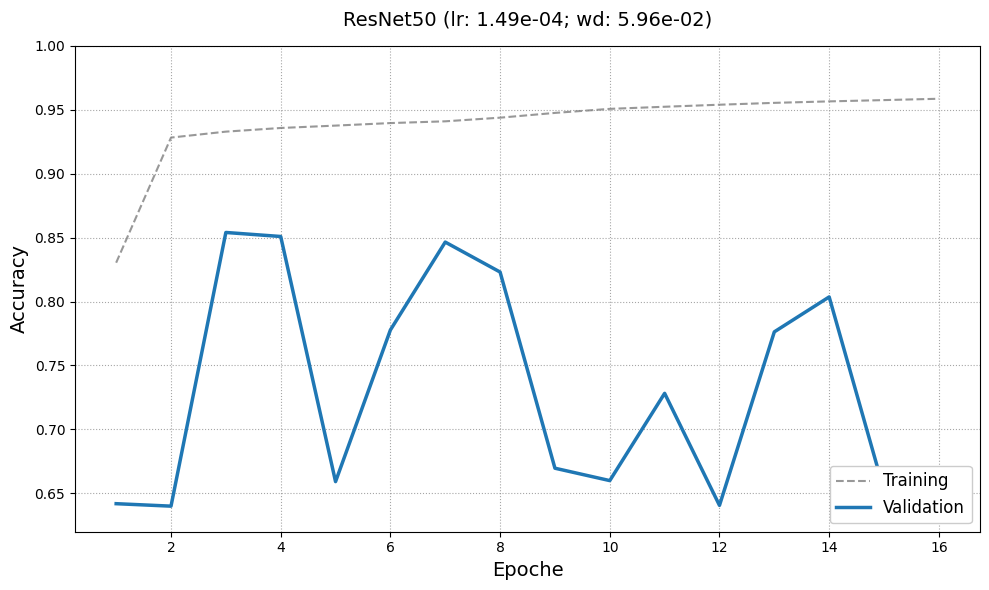

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def read_tensorboard_scalar(log_dir, tag="Accuracy"):
    """Liest die X- und Y-Werte einer bestimmten Kurve aus."""
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()
    
    if tag in event_acc.Tags().get('scalars', []):
        events = event_acc.Scalars(tag)
        steps = [e.step for e in events]
        vals = [e.value for e in events]
        return steps, vals
    else:
        print(f"⚠️ Warnung: Kurve '{tag}' in '{log_dir}' nicht gefunden.")
        return [], []

def plot_single_run(run_path, model_name):
    """Plottet Train und Val für einen einzelnen Run in Paper-Qualität."""
    plt.figure(figsize=(10, 6))
    
    # Pfade zu den Unterordnern bauen
    path_train = os.path.join(run_path, "Accuracy_train")
    path_val = os.path.join(run_path, "Accuracy_val")
    
    # Daten auslesen
    steps_train, vals_train = read_tensorboard_scalar(path_train, tag="Accuracy")
    steps_val, vals_val = read_tensorboard_scalar(path_val, tag="Accuracy")
    
    # Kontrastreiche Farben: Grau für Training, kräftiges Blau für Validation
    color_train = "#7f7f7f"
    color_val = "#1f77b4"
    
    # Minimum-Wert suchen, um die Y-Achse dynamisch anzupassen
    min_val = min(min(vals_train) if vals_train else 1.0, 
                  min(vals_val) if vals_val else 1.0)
    
    # 1. Training plotten (Gestrichelt)
    if steps_train and vals_train:
        plt.plot(steps_train, vals_train, color=color_train, linestyle="--", 
                 alpha=0.8, linewidth=1.5, label="Training")
        
    # 2. Validierung plotten (Durchgezogen, fett)
    if steps_val and vals_val:
        plt.plot(steps_val, vals_val, color=color_val, linestyle="-", 
                 alpha=1.0, linewidth=2.5, label="Validation")

    # --- Paper-Ready Styling ---
    # TITEL ENTFERNT! (Wird im LaTeX via \caption gemacht)
    plt.title(f"{model_name}", fontsize=14, pad=15)
    plt.xlabel("Epoche", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)
    
    # X-Achse: Nur ganze Zahlen! (Keine 2.5 Epochen mehr)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Y-Achse: Etwas unter dem echten Minimum starten, oben starr bei 1.0
    y_bottom = max(0.0, min_val - 0.02) # Puffer nach unten
    plt.ylim(y_bottom, 1.0)
    
    plt.grid(True, linestyle=":", alpha=0.7, color="gray")
    
    # Legende
    plt.legend(fontsize=12, loc="lower right", framealpha=1.0)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# AUSFÜHRUNG
# ==========================================
run_path = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search/RandomSearch_DM_time_binary_classificator_resnet50_dropout0.5-dmft_Container4/lr1.49e-04_wd5.96e-02"

# Funktion aufrufen (Dateiname ohne '.pdf' Endung übergeben)
plot_single_run(run_path, model_name="ResNet50 (lr: 1.49e-04; wd: 5.96e-02)")

✅ Plot gespeichert unter: resnet50_train_val_random_search.pdf


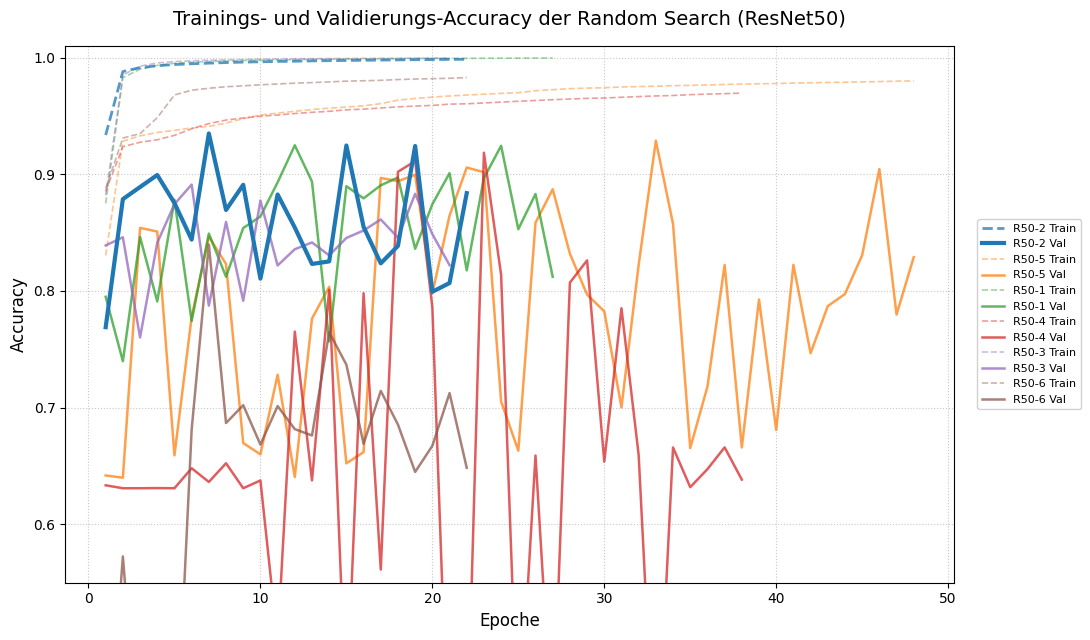


Ranking nach bester Validation Accuracy:
01. R50-2  dropout=0.4 lr=1.90e-04 wd=1.12e-03 val_best=0.9349 val_final=0.8838 train_final=0.9985
02. R50-5  dropout=0.5 lr=1.49e-04 wd=5.96e-02 val_best=0.9287 val_final=0.8289 train_final=0.9799
03. R50-1  dropout=0.3 lr=3.50e-05 wd=9.46e-03 val_best=0.9248 val_final=0.8121 train_final=0.9996
04. R50-4  dropout=0.5 lr=8.29e-04 wd=5.49e-03 val_best=0.9184 val_final=0.6384 train_final=0.9695
05. R50-3  dropout=0.4 lr=4.04e-05 wd=1.10e-03 val_best=0.8911 val_final=0.8221 train_final=0.9995
06. R50-6  dropout=0.5 lr=5.98e-04 wd=6.31e-03 val_best=0.8397 val_final=0.6485 train_final=0.9828


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy der Random Search (ResNet50)'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
resnet50_runs = {
    "R50-1": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search/RandomSearch_DM_time_binary_classificator_resnet50_dropout0.3-dmft_Container3/lr3.50e-05_wd9.46e-03",
        "dropout": 0.3,
        "lr": 3.50e-05,
        "wd": 9.46e-03,
    },
    "R50-2": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search/RandomSearch_DM_time_binary_classificator_resnet50_dropout0.4-dmft_Container0/lr1.90e-04_wd1.12e-03",
        "dropout": 0.4,
        "lr": 1.90e-04,
        "wd": 1.12e-03,
    },
    "R50-3": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search/RandomSearch_DM_time_binary_classificator_resnet50_dropout0.4-dmft_Container3/lr4.04e-05_wd1.10e-03",
        "dropout": 0.4,
        "lr": 4.04e-05,
        "wd": 1.10e-03,
    },
    "R50-4": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search/RandomSearch_DM_time_binary_classificator_resnet50_dropout0.5-dmft_Container1/lr8.29e-04_wd5.49e-03",
        "dropout": 0.5,
        "lr": 8.29e-04,
        "wd": 5.49e-03,
    },
    "R50-5": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search/RandomSearch_DM_time_binary_classificator_resnet50_dropout0.5-dmft_Container4/lr1.49e-04_wd5.96e-02",
        "dropout": 0.5,
        "lr": 1.49e-04,
        "wd": 5.96e-02,
    },
    "R50-6": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search/RandomSearch_DM_time_binary_classificator_resnet50_dropout0.5-dmft_Container4/lr5.98e-04_wd6.31e-03",
        "dropout": 0.5,
        "lr": 5.98e-04,
        "wd": 6.31e-03,
    },
}

import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


def read_tensorboard_scalar(log_dir, tag="Accuracy"):
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()

    if tag in event_acc.Tags().get("scalars", []):
        events = event_acc.Scalars(tag)
        steps = [e.step for e in events]
        vals = [e.value for e in events]
        return steps, vals

    print(f"⚠️ Warnung: Kurve '{tag}' in '{log_dir}' nicht gefunden.")
    return [], []


def plot_resnet50_train_val_runs(
    run_dict,
    model_name="ResNet50",
    save_path=None,
    highlight_best=True,
    ylim=(0.55, 1.01),
):
    fig, ax = plt.subplots(figsize=(11, 6.5))

    all_runs = []
    best_run_name = None
    best_val_acc = -1.0

    for run_name, run_info in run_dict.items():
        run_base_path = run_info["path"]

        path_train = os.path.join(run_base_path, "Accuracy_train")
        path_val = os.path.join(run_base_path, "Accuracy_val")

        steps_train, vals_train = read_tensorboard_scalar(path_train, tag="Accuracy")
        steps_val, vals_val = read_tensorboard_scalar(path_val, tag="Accuracy")

        if not steps_train and not steps_val:
            continue

        max_val = max(vals_val) if vals_val else float("nan")
        final_val = vals_val[-1] if vals_val else float("nan")
        max_train = max(vals_train) if vals_train else float("nan")
        final_train = vals_train[-1] if vals_train else float("nan")

        all_runs.append({
            "name": run_name,
            "dropout": run_info["dropout"],
            "lr": run_info["lr"],
            "wd": run_info["wd"],
            "steps_train": steps_train,
            "vals_train": vals_train,
            "steps_val": steps_val,
            "vals_val": vals_val,
            "max_val": max_val,
            "final_val": final_val,
            "max_train": max_train,
            "final_train": final_train,
        })

        if vals_val and max_val > best_val_acc:
            best_val_acc = max_val
            best_run_name = run_name

    if not all_runs:
        print("❌ Keine gültigen Runs gefunden.")
        return None

    all_runs = sorted(all_runs, key=lambda x: x["max_val"], reverse=True)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, run in enumerate(all_runs):
        color = color_cycle[i % len(color_cycle)]
        is_best = run["name"] == best_run_name

        if run["steps_train"] and run["vals_train"]:
            ax.plot(
                run["steps_train"],
                run["vals_train"],
                color=color,
                linestyle="--",
                linewidth=2.0 if is_best and highlight_best else 1.2,
                alpha=0.45 if not is_best else 0.75,
                label=f"{run['name']} Train",
                zorder=2 if not is_best else 4,
            )

        if run["steps_val"] and run["vals_val"]:
            ax.plot(
                run["steps_val"],
                run["vals_val"],
                color=color,
                linestyle="-",
                linewidth=3.0 if is_best and highlight_best else 1.8,
                alpha=1.0 if is_best and highlight_best else 0.75,
                label=f"{run['name']} Val",
                zorder=3 if not is_best else 5,
            )

    ax.set_title(f"Trainings- und Validierungs-Accuracy der Random Search ({model_name})", fontsize=14, pad=15)
    ax.set_xlabel("Epoche", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True, linestyle=":", alpha=0.7)

    ax.legend(
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        framealpha=0.9,
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        print(f"✅ Plot gespeichert unter: {save_path}")

    plt.show()

    print("\nRanking nach bester Validation Accuracy:")
    for i, run in enumerate(all_runs, start=1):
        print(
            f"{i:02d}. {run['name']:6s} "
            f"dropout={run['dropout']:.1f} "
            f"lr={run['lr']:.2e} "
            f"wd={run['wd']:.2e} "
            f"val_best={run['max_val']:.4f} "
            f"val_final={run['final_val']:.4f} "
            f"train_final={run['final_train']:.4f}"
        )

    return fig, ax
plot_resnet50_train_val_runs(
    resnet50_runs,
    model_name="ResNet50",
    save_path="resnet50_train_val_random_search.pdf",
    highlight_best=True,
    ylim=(0.55, 1.01),
)

⚠️ Warnung: Ordner fehlt oder wurde gelöscht: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.3-ft_Container9/lr3.07e-05_wd1.01e-02/Accuracy_train
⚠️ Warnung: Ordner fehlt oder wurde gelöscht: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.3-ft_Container9/lr3.07e-05_wd1.01e-02/Accuracy_val
✅ Plot gespeichert unter: resnet18_dmt_ft_train_val.pdf
✅ Plot gespeichert unter: resnet18_dmt_ft_train_val.pdf


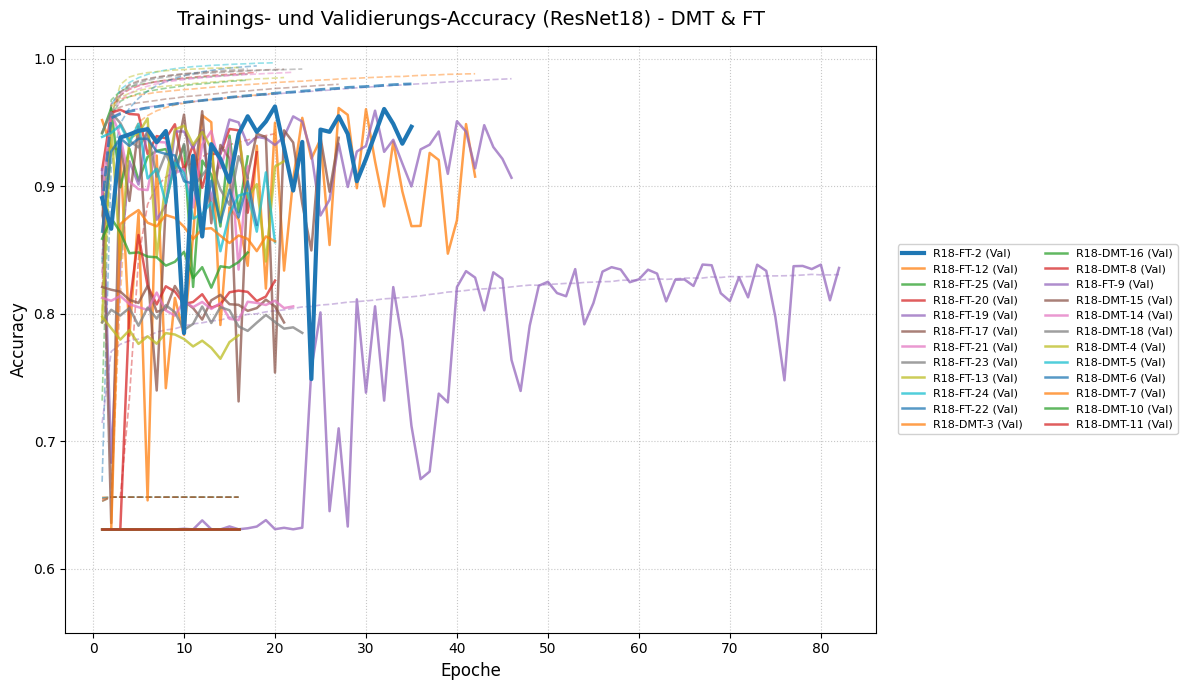


Ranking nach bester Validation Accuracy:
01. R18-FT-2   mode=ft  dropout=0.5 lr=9.05e-04 wd=1.29e-03 val_best=0.9625 train_final=0.9802
02. R18-FT-12  mode=ft  dropout=0.3 lr=6.51e-05 wd=6.89e-02 val_best=0.9613 train_final=0.9881
03. R18-FT-25  mode=ft  dropout=0.4 lr=1.39e-04 wd=3.27e-03 val_best=0.9610 train_final=0.9879
04. R18-FT-20  mode=ft  dropout=0.5 lr=5.76e-05 wd=7.82e-03 val_best=0.9599 train_final=0.9892
05. R18-FT-19  mode=ft  dropout=0.5 lr=6.72e-04 wd=1.88e-03 val_best=0.9592 train_final=0.9842
06. R18-FT-17  mode=ft  dropout=0.4 lr=1.06e-04 wd=5.13e-02 val_best=0.9587 train_final=0.9798
07. R18-FT-21  mode=ft  dropout=0.5 lr=9.89e-05 wd=3.41e-03 val_best=0.9576 train_final=0.9880
08. R18-FT-23  mode=ft  dropout=0.4 lr=5.05e-05 wd=7.25e-03 val_best=0.9576 train_final=0.9919
09. R18-FT-13  mode=ft  dropout=0.4 lr=3.94e-05 wd=6.02e-02 val_best=0.9531 train_final=0.9852
10. R18-FT-24  mode=ft  dropout=0.4 lr=6.09e-05 wd=1.21e-03 val_best=0.9489 train_final=0.9967
11. R18-

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy (ResNet18) - DMT & FT'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# HARDCODED RESNET18 RUNS
# ==========================================
resnet18_runs = {
    "R18-FT-1": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.3-ft_Container9/lr3.07e-05_wd1.01e-02",
        "dropout": 0.3,
        "lr": 3.07e-05,
        "wd": 0.0101,
        "mode": "ft",
    },
    "R18-FT-2": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.5-ft_Container10/lr9.05e-04_wd1.29e-03",
        "dropout": 0.5,
        "lr": 0.000905,
        "wd": 0.00129,
        "mode": "ft",
    },
    "R18-DMT-3": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.3-dmt_Container7/lr4.44e-05_wd1.28e-02",
        "dropout": 0.3,
        "lr": 4.44e-05,
        "wd": 0.0128,
        "mode": "dmt",
    },
    "R18-DMT-4": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.3-dmt_Container7/lr1.36e-05_wd6.71e-03",
        "dropout": 0.3,
        "lr": 1.36e-05,
        "wd": 0.00671,
        "mode": "dmt",
    },
    "R18-DMT-5": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-dmt_Container11/lr1.72e-04_wd6.03e-02",
        "dropout": 0.4,
        "lr": 0.000172,
        "wd": 0.0603,
        "mode": "dmt",
    },
    "R18-DMT-6": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-dmt_Container7/lr2.29e-04_wd3.29e-02",
        "dropout": 0.4,
        "lr": 0.000229,
        "wd": 0.0329,
        "mode": "dmt",
    },
    "R18-DMT-7": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.5-dmt_Container11/lr1.10e-04_wd2.94e-02",
        "dropout": 0.5,
        "lr": 0.00011,
        "wd": 0.0294,
        "mode": "dmt",
    },
    "R18-DMT-8": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.5-dmt_Container11/lr1.01e-04_wd9.23e-03",
        "dropout": 0.5,
        "lr": 0.000101,
        "wd": 0.00923,
        "mode": "dmt",
    },
    "R18-FT-9": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-ft_Container8/lr6.05e-04_wd2.43e-02",
        "dropout": 0.4,
        "lr": 0.000605,
        "wd": 0.0243,
        "mode": "ft",
    },
    "R18-DMT-10": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.5-dmt_Container9/lr3.25e-05_wd5.43e-02",
        "dropout": 0.5,
        "lr": 3.25e-05,
        "wd": 0.0543,
        "mode": "dmt",
    },
    "R18-DMT-11": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.5-dmt_Container9/lr3.11e-05_wd9.71e-02",
        "dropout": 0.5,
        "lr": 3.11e-05,
        "wd": 0.0971,
        "mode": "dmt",
    },
    "R18-FT-12": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.3-ft_Container10/lr6.51e-05_wd6.89e-02",
        "dropout": 0.3,
        "lr": 6.51e-05,
        "wd": 0.0689,
        "mode": "ft",
    },
    "R18-FT-13": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-ft_Container12/lr3.94e-05_wd6.02e-02",
        "dropout": 0.4,
        "lr": 3.94e-05,
        "wd": 0.0602,
        "mode": "ft",
    },
    "R18-DMT-14": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-dmt_Container5/lr5.05e-05_wd7.25e-03",
        "dropout": 0.4,
        "lr": 5.05e-05,
        "wd": 0.00725,
        "mode": "dmt",
    },
    "R18-DMT-15": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-dmt_Container5/lr6.09e-05_wd1.21e-03",
        "dropout": 0.4,
        "lr": 6.09e-05,
        "wd": 0.00121,
        "mode": "dmt",
    },
    "R18-DMT-16": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-dmt_Container5/lr1.39e-04_wd3.27e-03",
        "dropout": 0.4,
        "lr": 0.000139,
        "wd": 0.00327,
        "mode": "dmt",
    },
    "R18-FT-17": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-ft_Container10/lr1.06e-04_wd5.13e-02",
        "dropout": 0.4,
        "lr": 0.000106,
        "wd": 0.0513,
        "mode": "ft",
    },
    "R18-DMT-18": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.3-dmt_Container9/lr3.07e-05_wd1.01e-02",
        "dropout": 0.3,
        "lr": 3.07e-05,
        "wd": 0.0101,
        "mode": "dmt",
    },
    "R18-FT-19": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.5-ft_Container12/lr6.72e-04_wd1.88e-03",
        "dropout": 0.5,
        "lr": 0.000672,
        "wd": 0.00188,
        "mode": "ft",
    },
    "R18-FT-20": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.5-ft_Container12/lr5.76e-05_wd7.82e-03",
        "dropout": 0.5,
        "lr": 5.76e-05,
        "wd": 0.00782,
        "mode": "ft",
    },
    "R18-FT-21": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.5-ft_Container8/lr9.89e-05_wd3.41e-03",
        "dropout": 0.5,
        "lr": 9.89e-05,
        "wd": 0.00341,
        "mode": "ft",
    },
    "R18-FT-22": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.5-ft_Container8/lr1.48e-05_wd4.31e-03",
        "dropout": 0.5,
        "lr": 1.48e-05,
        "wd": 0.00431,
        "mode": "ft",
    },
    "R18-FT-23": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-ft_Container5/lr5.05e-05_wd7.25e-03",
        "dropout": 0.4,
        "lr": 5.05e-05,
        "wd": 0.00725,
        "mode": "ft",
    },
    "R18-FT-24": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-ft_Container5/lr6.09e-05_wd1.21e-03",
        "dropout": 0.4,
        "lr": 6.09e-05,
        "wd": 0.00121,
        "mode": "ft",
    },
    "R18-FT-25": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_random_search_dmt_ft/RandomSearch_DM_time_binary_classificator_resnet18_dropout0.4-ft_Container5/lr1.39e-04_wd3.27e-03",
        "dropout": 0.4,
        "lr": 0.000139,
        "wd": 0.00327,
        "mode": "ft",
    },
}

# ==========================================
# PLOTTING FUNKTIONEN
# ==========================================
def read_tensorboard_scalar(log_dir, tag="Accuracy"):
    if not os.path.exists(log_dir):
        print(f"⚠️ Warnung: Ordner fehlt oder wurde gelöscht: {log_dir}")
        return [], []

    try:
        event_acc = EventAccumulator(log_dir)
        event_acc.Reload()

        if tag in event_acc.Tags().get("scalars", []):
            events = event_acc.Scalars(tag)
            steps = [e.step for e in events]
            vals = [e.value for e in events]
            return steps, vals
    except Exception as e:
        print(f"⚠️ Warnung: Fehler beim Laden von {log_dir}: {e}")

    return [], []


def plot_train_val_runs(
    run_dict,
    model_name="ResNet18",
    save_path=None,
    highlight_best=True,
    ylim=(0.55, 1.01),
):
    fig, ax = plt.subplots(figsize=(12, 7))

    all_runs = []
    best_run_name = None
    best_val_acc = -1.0

    for run_name, run_info in run_dict.items():
        run_base_path = run_info["path"]

        path_train = os.path.join(run_base_path, "Accuracy_train")
        path_val = os.path.join(run_base_path, "Accuracy_val")

        steps_train, vals_train = read_tensorboard_scalar(path_train, tag="Accuracy")
        steps_val, vals_val = read_tensorboard_scalar(path_val, tag="Accuracy")

        if not steps_train and not steps_val:
            continue

        max_val = max(vals_val) if vals_val else float("nan")
        final_val = vals_val[-1] if vals_val else float("nan")
        max_train = max(vals_train) if vals_train else float("nan")
        final_train = vals_train[-1] if vals_train else float("nan")

        all_runs.append({
            "name": run_name,
            "dropout": run_info["dropout"],
            "lr": run_info["lr"],
            "wd": run_info["wd"],
            "mode": run_info.get("mode", "unknown"),
            "steps_train": steps_train,
            "vals_train": vals_train,
            "steps_val": steps_val,
            "vals_val": vals_val,
            "max_val": max_val,
            "final_val": final_val,
            "max_train": max_train,
            "final_train": final_train,
        })

        if vals_val and max_val > best_val_acc:
            best_val_acc = max_val
            best_run_name = run_name

    if not all_runs:
        print("❌ Keine gültigen Runs gefunden.")
        return None

    all_runs = sorted(all_runs, key=lambda x: x["max_val"], reverse=True)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, run in enumerate(all_runs):
        color = color_cycle[i % len(color_cycle)]
        is_best = run["name"] == best_run_name

        if run["steps_train"] and run["vals_train"]:
            ax.plot(
                run["steps_train"],
                run["vals_train"],
                color=color,
                linestyle="--",
                linewidth=2.0 if is_best and highlight_best else 1.2,
                alpha=0.45 if not is_best else 0.75,
                zorder=2 if not is_best else 4,
            )

        if run["steps_val"] and run["vals_val"]:
            ax.plot(
                run["steps_val"],
                run["vals_val"],
                color=color,
                linestyle="-",
                linewidth=3.0 if is_best and highlight_best else 1.8,
                alpha=1.0 if is_best and highlight_best else 0.75,
                label=f"{run['name']} (Val)",
                zorder=3 if not is_best else 5,
            )

    ax.set_title(f"Trainings- und Validierungs-Accuracy ({model_name}) - DMT & FT", fontsize=14, pad=15)
    ax.set_xlabel("Epoche", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True, linestyle=":", alpha=0.7)

    # Legende rechts platzieren
    ax.legend(
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        framealpha=0.9,
        ncol=2 # Zwei Spalten falls es sehr viele sind
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        print(f"✅ Plot gespeichert unter: {save_path}")

    plt.show()

    print("\nRanking nach bester Validation Accuracy:")
    for i, run in enumerate(all_runs, start=1):
        print(
            f"{i:02d}. {run['name']:10s} "
            f"mode={run['mode']:3s} "
            f"dropout={run['dropout']:.1f} "
            f"lr={run['lr']:.2e} "
            f"wd={run['wd']:.2e} "
            f"val_best={run['max_val']:.4f} "
            f"train_final={run['final_train']:.4f}"
        )

    return fig, ax

plot_train_val_runs(
    resnet18_runs,
    model_name="ResNet18",
    save_path="resnet18_dmt_ft_train_val.pdf",
    highlight_best=True,
    ylim=(0.55, 1.01),
)

✅ Plot gespeich(ert unter: rejector_2_gap_train_val.pdf


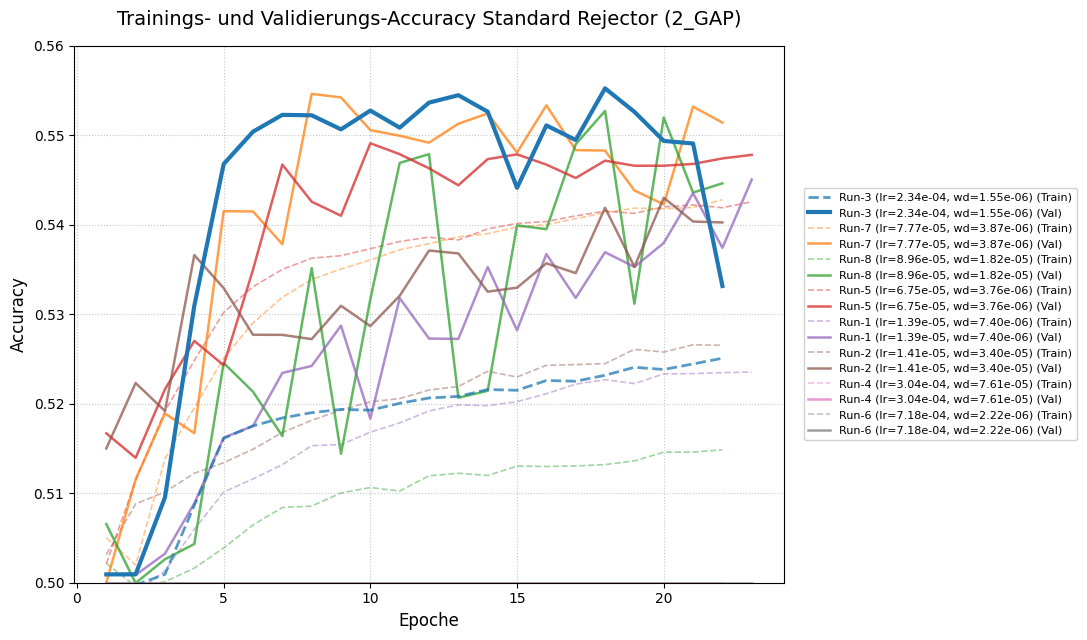

✅ Plot gespeich(ert unter: rejector_2_gap_train_val.pdf


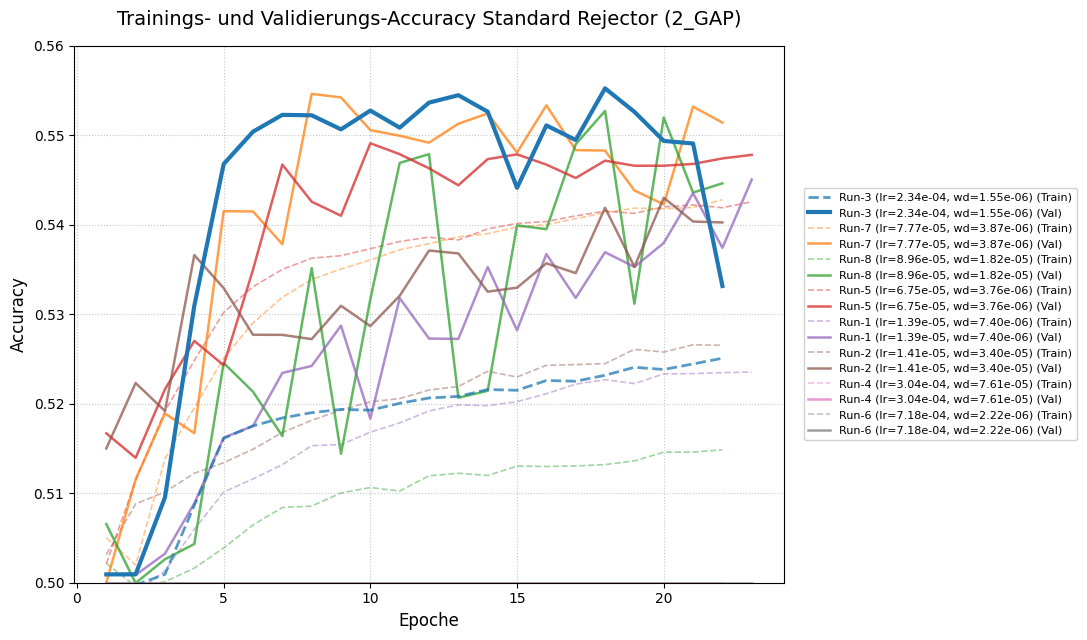


Ranking nach bester Validation Accuracy:
01. Run-3 (lr=2.34e-04, wd=1.55e-06) lr=2.34e-04 wd=1.55e-06 val_best=0.5552 train_final=0.5251
02. Run-7 (lr=7.77e-05, wd=3.87e-06) lr=7.77e-05 wd=3.87e-06 val_best=0.5546 train_final=0.5428
03. Run-8 (lr=8.96e-05, wd=1.82e-05) lr=8.96e-05 wd=1.82e-05 val_best=0.5527 train_final=0.5149
04. Run-5 (lr=6.75e-05, wd=3.76e-06) lr=6.75e-05 wd=3.76e-06 val_best=0.5491 train_final=0.5426
05. Run-1 (lr=1.39e-05, wd=7.40e-06) lr=1.39e-05 wd=7.40e-06 val_best=0.5451 train_final=0.5235
06. Run-2 (lr=1.41e-05, wd=3.40e-05) lr=1.41e-05 wd=3.40e-05 val_best=0.5430 train_final=0.5265
07. Run-4 (lr=3.04e-04, wd=7.61e-05) lr=3.04e-04 wd=7.61e-05 val_best=0.5000 train_final=0.4992
08. Run-6 (lr=7.18e-04, wd=2.22e-06) lr=7.18e-04 wd=2.22e-06 val_best=0.5000 train_final=0.4987


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Standard Rejector (2_GAP)'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# HARDCODED REJECTOR RUNS
# ==========================================
rejector_runs_2_gap = {
    "Run-1 (lr=1.39e-05, wd=7.40e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr1.39e-05_wd7.40e-06_drop0.0_channels128_extraTrue_worker24_trial0",
        "lr": 1.39e-05,
        "wd": 7.40e-06,
    },
    "Run-2 (lr=1.41e-05, wd=3.40e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr1.41e-05_wd3.40e-05_drop0.0_channels128_extraTrue_worker25_trial0",
        "lr": 1.41e-05,
        "wd": 3.40e-05,
    },
    "Run-3 (lr=2.34e-04, wd=1.55e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr2.34e-04_wd1.55e-06_drop0.0_channels64_extraTrue_worker27_trial0",
        "lr": 2.34e-04,
        "wd": 1.55e-06,
    },
    "Run-4 (lr=3.04e-04, wd=7.61e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr3.04e-04_wd7.61e-05_drop0.0_channels64_extraTrue_worker26_trial0",
        "lr": 3.04e-04,
        "wd": 7.61e-05,
    },
    "Run-5 (lr=6.75e-05, wd=3.76e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr6.75e-05_wd3.76e-06_drop0.0_channels128_extraTrue_worker23_trial0",
        "lr": 6.75e-05,
        "wd": 3.76e-06,
    },
    "Run-6 (lr=7.18e-04, wd=2.22e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr7.18e-04_wd2.22e-06_drop0.0_channels128_extraTrue_worker20_trial0",
        "lr": 7.18e-04,
        "wd": 2.22e-06,
    },
    "Run-7 (lr=7.77e-05, wd=3.87e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr7.77e-05_wd3.87e-06_drop0.0_channels128_extraTrue_worker21_trial0",
        "lr": 7.77e-05,
        "wd": 3.87e-06,
    },
    "Run-8 (lr=8.96e-05, wd=1.82e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr8.96e-05_wd1.82e-05_drop0.0_channels64_extraTrue_worker22_trial0",
        "lr": 8.96e-05,
        "wd": 1.82e-05,
    },
}

def read_tensorboard_scalar(log_dir, tag="Accuracy"):
    if not os.path.exists(log_dir):
        return [], []

    try:
        event_acc = EventAccumulator(log_dir)
        event_acc.Reload()

        if tag in event_acc.Tags().get("scalars", []):
            events = event_acc.Scalars(tag)
            steps = [e.step for e in events]
            vals = [e.value for e in events]
            return steps, vals
    except Exception as e:
        print(f"⚠️ Warnung: Fehler beim Laden von {log_dir}: {e}")

    return [], []

def plot_rejector_train_val(
    run_dict,
    model_name="Rejector (2_GAP)",
    save_path=None,
    highlight_best=True,
    ylim=(0.5, 1.01),
):
    fig, ax = plt.subplots(figsize=(11, 6.5))

    all_runs = []
    best_run_name = None
    best_val_acc = -1.0

    for run_name, run_info in run_dict.items():
        run_base_path = run_info["path"]

        path_train = os.path.join(run_base_path, "Accuracy_train")
        path_val = os.path.join(run_base_path, "Accuracy_val")

        steps_train, vals_train = read_tensorboard_scalar(path_train, tag="Accuracy")
        steps_val, vals_val = read_tensorboard_scalar(path_val, tag="Accuracy")

        if not steps_train and not steps_val:
            continue

        max_val = max(vals_val) if vals_val else float("nan")
        final_val = vals_val[-1] if vals_val else float("nan")
        max_train = max(vals_train) if vals_train else float("nan")
        final_train = vals_train[-1] if vals_train else float("nan")

        all_runs.append({
            "name": run_name,
            "lr": run_info["lr"],
            "wd": run_info["wd"],
            "steps_train": steps_train,
            "vals_train": vals_train,
            "steps_val": steps_val,
            "vals_val": vals_val,
            "max_val": max_val,
            "final_val": final_val,
            "max_train": max_train,
            "final_train": final_train,
        })

        if vals_val and max_val > best_val_acc:
            best_val_acc = max_val
            best_run_name = run_name

    if not all_runs:
        print("❌ Keine gültigen Runs gefunden.")
        return None

    all_runs = sorted(all_runs, key=lambda x: x["max_val"], reverse=True)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, run in enumerate(all_runs):
        color = color_cycle[i % len(color_cycle)]
        is_best = run["name"] == best_run_name

        if run["steps_train"] and run["vals_train"]:
            ax.plot(
                run["steps_train"],
                run["vals_train"],
                color=color,
                linestyle="--",
                linewidth=2.0 if is_best and highlight_best else 1.2,
                alpha=0.45 if not is_best else 0.75,
                label=f"{run['name']} (Train)",
                zorder=2 if not is_best else 4,
            )

        if run["steps_val"] and run["vals_val"]:
            ax.plot(
                run["steps_val"],
                run["vals_val"],
                color=color,
                linestyle="-",
                linewidth=3.0 if is_best and highlight_best else 1.8,
                alpha=1.0 if is_best and highlight_best else 0.75,
                label=f"{run['name']} (Val)",
                zorder=3 if not is_best else 5,
            )

    ax.set_title(f"Trainings- und Validierungs-Accuracy {model_name}", fontsize=14, pad=15)
    ax.set_xlabel("Epoche", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True, linestyle=":", alpha=0.7)

    # Legende rechts platzieren
    ax.legend(
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        framealpha=0.9,
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        print(f"✅ Plot gespeich(ert unter: {save_path}")

    plt.show()

    print("\nRanking nach bester Validation Accuracy:")
    for i, run in enumerate(all_runs, start=1):
        print(
            f"{i:02d}. {run['name']:30s} "
            f"lr={run['lr']:.2e} "
            f"wd={run['wd']:.2e} "
            f"val_best={run['max_val']:.4f} "
            f"train_final={run['final_train']:.4f}"
        )

    return fig, ax

plot_rejector_train_val(
    rejector_runs_2_gap,
    model_name="Standard Rejector (2_GAP)",
    save_path="rejector_2_gap_train_val.pdf",
    highlight_best=True,
    ylim=(0.5, 0.56),
)

✅ Plot gespeich(ert unter: rejector_2_gap_train_val.pdf


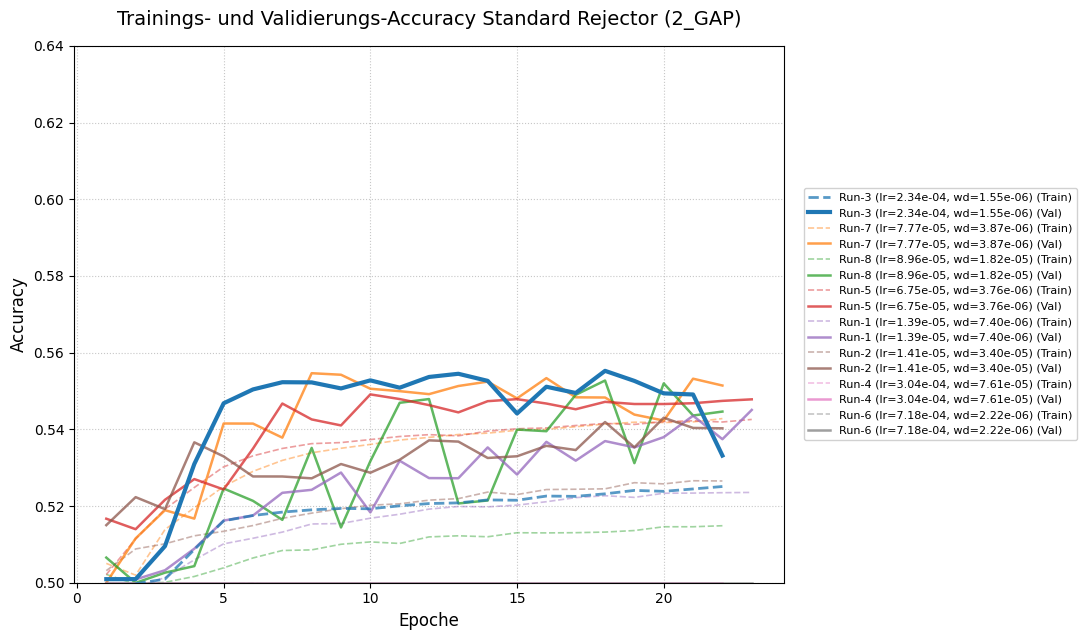


Ranking nach bester Validation Accuracy:
01. Run-3 (lr=2.34e-04, wd=1.55e-06) lr=2.34e-04 wd=1.55e-06 val_best=0.5552 train_final=0.5251
02. Run-7 (lr=7.77e-05, wd=3.87e-06) lr=7.77e-05 wd=3.87e-06 val_best=0.5546 train_final=0.5428
03. Run-8 (lr=8.96e-05, wd=1.82e-05) lr=8.96e-05 wd=1.82e-05 val_best=0.5527 train_final=0.5149
04. Run-5 (lr=6.75e-05, wd=3.76e-06) lr=6.75e-05 wd=3.76e-06 val_best=0.5491 train_final=0.5426
05. Run-1 (lr=1.39e-05, wd=7.40e-06) lr=1.39e-05 wd=7.40e-06 val_best=0.5451 train_final=0.5235
06. Run-2 (lr=1.41e-05, wd=3.40e-05) lr=1.41e-05 wd=3.40e-05 val_best=0.5430 train_final=0.5265
07. Run-4 (lr=3.04e-04, wd=7.61e-05) lr=3.04e-04 wd=7.61e-05 val_best=0.5000 train_final=0.4992
08. Run-6 (lr=7.18e-04, wd=2.22e-06) lr=7.18e-04 wd=2.22e-06 val_best=0.5000 train_final=0.4987


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Standard Rejector (2_GAP)'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# HARDCODED REJECTOR RUNS
# ==========================================
rejector_runs_2_gap = {
    "Run-1 (lr=1.39e-05, wd=7.40e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr1.39e-05_wd7.40e-06_drop0.0_channels128_extraTrue_worker24_trial0",
        "lr": 1.39e-05,
        "wd": 7.40e-06,
    },
    "Run-2 (lr=1.41e-05, wd=3.40e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr1.41e-05_wd3.40e-05_drop0.0_channels128_extraTrue_worker25_trial0",
        "lr": 1.41e-05,
        "wd": 3.40e-05,
    },
    "Run-3 (lr=2.34e-04, wd=1.55e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr2.34e-04_wd1.55e-06_drop0.0_channels64_extraTrue_worker27_trial0",
        "lr": 2.34e-04,
        "wd": 1.55e-06,
    },
    "Run-4 (lr=3.04e-04, wd=7.61e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr3.04e-04_wd7.61e-05_drop0.0_channels64_extraTrue_worker26_trial0",
        "lr": 3.04e-04,
        "wd": 7.61e-05,
    },
    "Run-5 (lr=6.75e-05, wd=3.76e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr6.75e-05_wd3.76e-06_drop0.0_channels128_extraTrue_worker23_trial0",
        "lr": 6.75e-05,
        "wd": 3.76e-06,
    },
    "Run-6 (lr=7.18e-04, wd=2.22e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr7.18e-04_wd2.22e-06_drop0.0_channels128_extraTrue_worker20_trial0",
        "lr": 7.18e-04,
        "wd": 2.22e-06,
    },
    "Run-7 (lr=7.77e-05, wd=3.87e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr7.77e-05_wd3.87e-06_drop0.0_channels128_extraTrue_worker21_trial0",
        "lr": 7.77e-05,
        "wd": 3.87e-06,
    },
    "Run-8 (lr=8.96e-05, wd=1.82e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_2_GAP_lr8.96e-05_wd1.82e-05_drop0.0_channels64_extraTrue_worker22_trial0",
        "lr": 8.96e-05,
        "wd": 1.82e-05,
    },
}

import os
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


def read_tensorboard_scalar(log_dir, tag="Accuracy", verbose=False):
    if not os.path.exists(log_dir):
        return [], []

    log_dir = Path(log_dir)
    event_files = sorted(log_dir.glob("events.out.tfevents.*"))

    # Fallback: falls keine einzelnen Event-Dateien gefunden werden
    if not event_files:
        try:
            event_acc = EventAccumulator(str(log_dir), size_guidance={"scalars": 0})
            event_acc.Reload()

            if tag in event_acc.Tags().get("scalars", []):
                events = event_acc.Scalars(tag)
                steps = [e.step for e in events]
                vals = [e.value for e in events]
                return steps, vals

        except Exception as e:
            print(f"⚠️ Warnung: Fehler beim Laden von {log_dir}: {e}")

        return [], []

    best_file = None
    best_events = None
    best_score = None

    for event_file in event_files:
        try:
            event_acc = EventAccumulator(str(event_file), size_guidance={"scalars": 0})
            event_acc.Reload()

            if tag not in event_acc.Tags().get("scalars", []):
                continue

            events = event_acc.Scalars(tag)

            if not events:
                continue

            steps = [e.step for e in events]
            unique_steps = len(set(steps))
            max_step = max(steps)

            # "meiste Epochen" = größter max_step;
            # Tie-Breaker: mehr eindeutige Steps, danach spätere Änderungszeit
            score = (
                max_step,
                unique_steps,
                event_file.stat().st_mtime,
            )

            if best_score is None or score > best_score:
                best_score = score
                best_file = event_file
                best_events = events

        except Exception as e:
            print(f"⚠️ Warnung: Fehler beim Laden von {event_file}: {e}")

    if best_events is None:
        return [], []

    # Nach Step sortieren
    pairs = sorted([(e.step, e.value) for e in best_events], key=lambda x: x[0])

    # Falls innerhalb derselben Datei ein Step mehrfach vorkommt: letzten Wert behalten
    step_to_val = {}
    for step, val in pairs:
        step_to_val[step] = val

    steps = list(step_to_val.keys())
    vals = list(step_to_val.values())

    if verbose:
        print(f"✅ Geladene Event-Datei: {best_file}")
        print(f"   Punkte: {len(steps)}")
        print(f"   Steps:  {min(steps)} bis {max(steps)}")
        print(f"   Final:  {vals[-1]:.4f}")
        print(f"   Best:   {max(vals):.4f}")

    return steps, vals

def plot_rejector_train_val(
    run_dict,
    model_name="Rejector (2_GAP)",
    save_path=None,
    highlight_best=True,
    ylim=(0.5, 1.01),
):
    fig, ax = plt.subplots(figsize=(11, 6.5))

    all_runs = []
    best_run_name = None
    best_val_acc = -1.0

    for run_name, run_info in run_dict.items():
        run_base_path = run_info["path"]

        path_train = os.path.join(run_base_path, "Accuracy_train")
        path_val = os.path.join(run_base_path, "Accuracy_val")

        steps_train, vals_train = read_tensorboard_scalar(path_train, tag="Accuracy")
        steps_val, vals_val = read_tensorboard_scalar(path_val, tag="Accuracy")

        if not steps_train and not steps_val:
            continue

        max_val = max(vals_val) if vals_val else float("nan")
        final_val = vals_val[-1] if vals_val else float("nan")
        max_train = max(vals_train) if vals_train else float("nan")
        final_train = vals_train[-1] if vals_train else float("nan")

        all_runs.append({
            "name": run_name,
            "lr": run_info["lr"],
            "wd": run_info["wd"],
            "steps_train": steps_train,
            "vals_train": vals_train,
            "steps_val": steps_val,
            "vals_val": vals_val,
            "max_val": max_val,
            "final_val": final_val,
            "max_train": max_train,
            "final_train": final_train,
        })

        if vals_val and max_val > best_val_acc:
            best_val_acc = max_val
            best_run_name = run_name

    if not all_runs:
        print("❌ Keine gültigen Runs gefunden.")
        return None

    all_runs = sorted(all_runs, key=lambda x: x["max_val"], reverse=True)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, run in enumerate(all_runs):
        color = color_cycle[i % len(color_cycle)]
        is_best = run["name"] == best_run_name

        if run["steps_train"] and run["vals_train"]:
            ax.plot(
                run["steps_train"],
                run["vals_train"],
                color=color,
                linestyle="--",
                linewidth=2.0 if is_best and highlight_best else 1.2,
                alpha=0.45 if not is_best else 0.75,
                label=f"{run['name']} (Train)",
                zorder=2 if not is_best else 4,
            )

        if run["steps_val"] and run["vals_val"]:
            ax.plot(
                run["steps_val"],
                run["vals_val"],
                color=color,
                linestyle="-",
                linewidth=3.0 if is_best and highlight_best else 1.8,
                alpha=1.0 if is_best and highlight_best else 0.75,
                label=f"{run['name']} (Val)",
                zorder=3 if not is_best else 5,
            )

    ax.set_title(f"Trainings- und Validierungs-Accuracy {model_name}", fontsize=14, pad=15)
    ax.set_xlabel("Epoche", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True, linestyle=":", alpha=0.7)

    # Legende rechts platzieren
    ax.legend(
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        framealpha=0.9,
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        print(f"✅ Plot gespeich(ert unter: {save_path}")

    plt.show()

    print("\nRanking nach bester Validation Accuracy:")
    for i, run in enumerate(all_runs, start=1):
        print(
            f"{i:02d}. {run['name']:30s} "
            f"lr={run['lr']:.2e} "
            f"wd={run['wd']:.2e} "
            f"val_best={run['max_val']:.4f} "
            f"train_final={run['final_train']:.4f}"
        )

    return fig, ax

plot_rejector_train_val(
    rejector_runs_2_gap,
    model_name="Standard Rejector (2_GAP)",
    save_path="rejector_2_gap_train_val.pdf",
    highlight_best=True,
    ylim=(0.5, 0.64),
)

✅ Plot gespeich(ert unter: rejector_3_gap_train_val.pdf


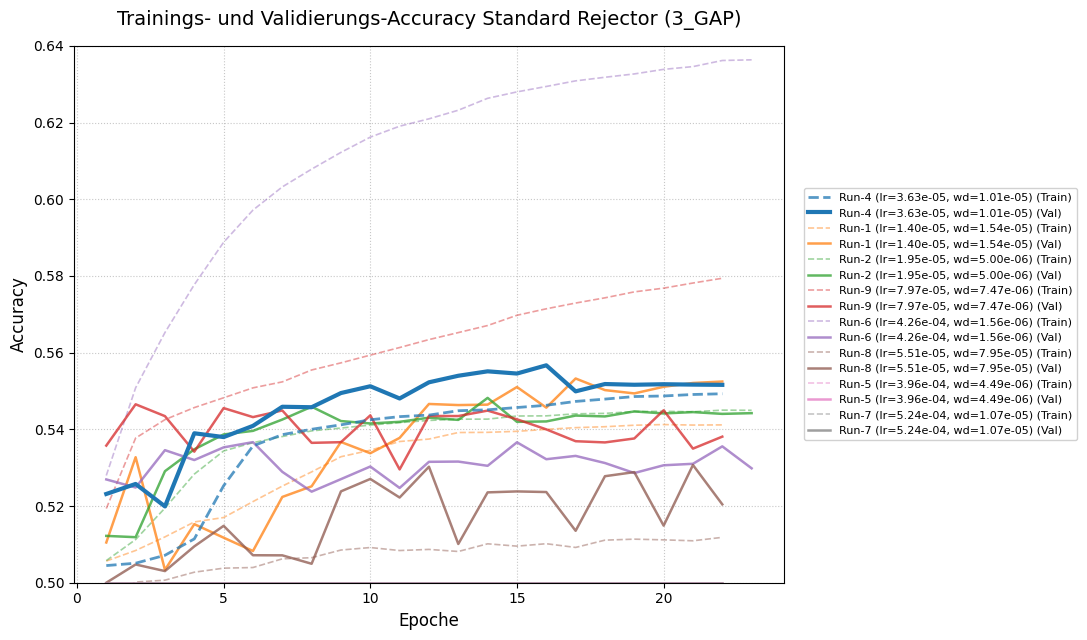


Ranking nach bester Validation Accuracy:
01. Run-4 (lr=3.63e-05, wd=1.01e-05) lr=3.63e-05 wd=1.01e-05 val_best=0.5567 train_final=0.5493
02. Run-1 (lr=1.40e-05, wd=1.54e-05) lr=1.40e-05 wd=1.54e-05 val_best=0.5533 train_final=0.5412
03. Run-2 (lr=1.95e-05, wd=5.00e-06) lr=1.95e-05 wd=5.00e-06 val_best=0.5482 train_final=0.5450
04. Run-9 (lr=7.97e-05, wd=7.47e-06) lr=7.97e-05 wd=7.47e-06 val_best=0.5465 train_final=0.5794
05. Run-6 (lr=4.26e-04, wd=1.56e-06) lr=4.26e-04 wd=1.56e-06 val_best=0.5367 train_final=0.6364
06. Run-8 (lr=5.51e-05, wd=7.95e-05) lr=5.51e-05 wd=7.95e-05 val_best=0.5307 train_final=0.5118
07. Run-5 (lr=3.96e-04, wd=4.49e-06) lr=3.96e-04 wd=4.49e-06 val_best=0.5000 train_final=0.4993
08. Run-7 (lr=5.24e-04, wd=1.07e-05) lr=5.24e-04 wd=1.07e-05 val_best=0.5000 train_final=0.4990


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Standard Rejector (3_GAP)'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# HARDCODED REJECTOR RUNS (3_GAP)
# ==========================================
rejector_runs_3_gap = {
    "Run-1 (lr=1.40e-05, wd=1.54e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_3_GAP_lr1.40e-05_wd1.54e-05_drop0.0_channels128_extraTrue_worker30_trial0",
        "lr": 1.40e-05,
        "wd": 1.54e-05,
    },
    "Run-2 (lr=1.95e-05, wd=5.00e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_3_GAP_lr1.95e-05_wd5.00e-06_drop0.0_channels64_extraTrue_worker37_trial0",
        "lr": 1.95e-05,
        "wd": 5.00e-06,
    },
    "Run-3 (lr=3.49e-05, wd=1.21e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_3_GAP_lr3.49e-05_wd1.21e-05_drop0.0_channels128_extraTrue_worker38_trial0",
        "lr": 3.49e-05,
        "wd": 1.21e-05,
    },
    "Run-4 (lr=3.63e-05, wd=1.01e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_3_GAP_lr3.63e-05_wd1.01e-05_drop0.0_channels128_extraTrue_worker31_trial0",
        "lr": 3.63e-05,
        "wd": 1.01e-05,
    },
    "Run-5 (lr=3.96e-04, wd=4.49e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_3_GAP_lr3.96e-04_wd4.49e-06_drop0.0_channels64_extraTrue_worker35_trial0",
        "lr": 3.96e-04,
        "wd": 4.49e-06,
    },
    "Run-6 (lr=4.26e-04, wd=1.56e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_3_GAP_lr4.26e-04_wd1.56e-06_drop0.0_channels128_extraTrue_worker36_trial0",
        "lr": 4.26e-04,
        "wd": 1.56e-06,
    },
    "Run-7 (lr=5.24e-04, wd=1.07e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_3_GAP_lr5.24e-04_wd1.07e-05_drop0.0_channels128_extraTrue_worker32_trial0",
        "lr": 5.24e-04,
        "wd": 1.07e-05,
    },
    "Run-8 (lr=5.51e-05, wd=7.95e-05)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_3_GAP_lr5.51e-05_wd7.95e-05_drop0.0_channels128_extraTrue_worker34_trial0",
        "lr": 5.51e-05,
        "wd": 7.95e-05,
    },
    "Run-9 (lr=7.97e-05, wd=7.47e-06)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/standard/run_standard_3_GAP_lr7.97e-05_wd7.47e-06_drop0.0_channels128_extraTrue_worker33_trial0",
        "lr": 7.97e-05,
        "wd": 7.47e-06,
    },
}


plot_rejector_train_val(
    rejector_runs_3_gap,
    model_name="Standard Rejector (3_GAP)",
    save_path="rejector_3_gap_train_val.pdf",
    highlight_best=True,
    ylim=(0.5, 0.64),
)

✅ Plot gespeich(ert unter: rejector_embedding_train_val.pdf


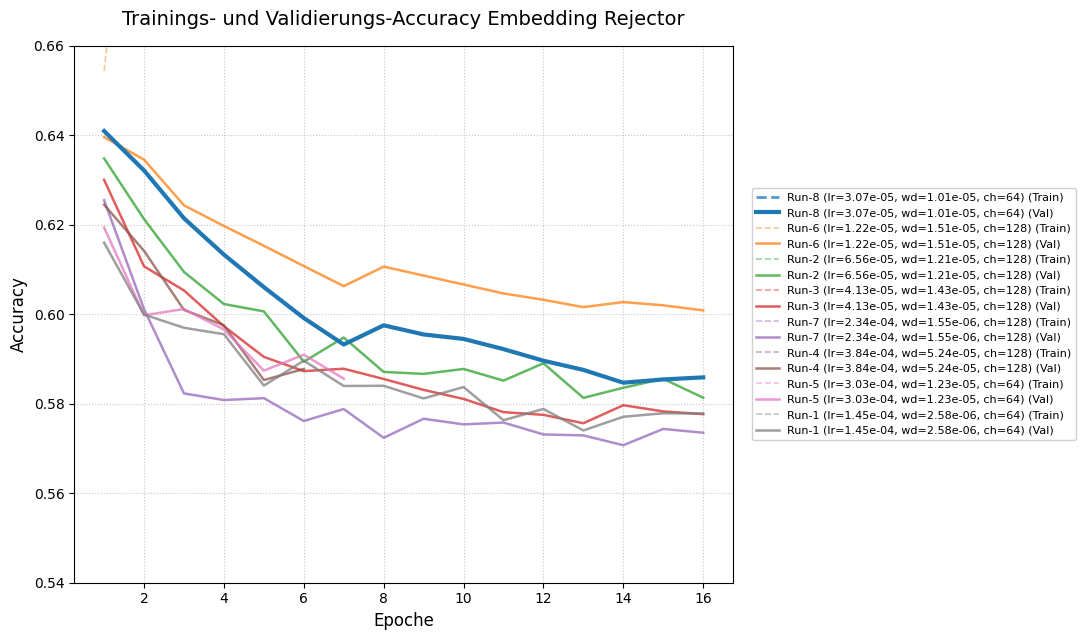


Ranking nach bester Validation Accuracy:
01. Run-8 (lr=3.07e-05, wd=1.01e-05, ch=64) lr=3.07e-05 wd=1.01e-05 val_best=0.6410 train_final=0.9942
02. Run-6 (lr=1.22e-05, wd=1.51e-05, ch=128) lr=1.22e-05 wd=1.51e-05 val_best=0.6396 train_final=0.9567
03. Run-2 (lr=6.56e-05, wd=1.21e-05, ch=128) lr=6.56e-05 wd=1.21e-05 val_best=0.6348 train_final=0.9968
04. Run-3 (lr=4.13e-05, wd=1.43e-05, ch=128) lr=4.13e-05 wd=1.43e-05 val_best=0.6300 train_final=0.9952
05. Run-7 (lr=2.34e-04, wd=1.55e-06, ch=128) lr=2.34e-04 wd=1.55e-06 val_best=0.6255 train_final=0.9970
06. Run-4 (lr=3.84e-04, wd=5.24e-05, ch=128) lr=3.84e-04 wd=5.24e-05 val_best=0.6245 train_final=0.9473
07. Run-5 (lr=3.03e-04, wd=1.23e-05, ch=64) lr=3.03e-04 wd=1.23e-05 val_best=0.6194 train_final=0.9540
08. Run-1 (lr=1.45e-04, wd=2.58e-06, ch=64) lr=1.45e-04 wd=2.58e-06 val_best=0.6160 train_final=0.9975


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Embedding Rejector'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# HARDCODED REJECTOR RUNS (Embedding)
# ==========================================
rejector_runs_embedding = {
    "Run-1 (lr=1.19e-05, wd=2.47e-05, ch=32)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/embedding/run_embedding_lr1.19e-05_wd2.47e-05_drop0.0_channels32_worker1_trial0",
        "lr": 1.19e-05,
        "wd": 2.47e-05,
        "channels": 32,
    },
    "Run-2 (lr=1.25e-04, wd=1.84e-06, ch=64)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/embedding/run_embedding_lr1.25e-04_wd1.84e-06_drop0.0_channels64_worker6_trial0",
        "lr": 1.25e-04,
        "wd": 1.84e-06,
        "channels": 64,
    },
    "Run-3 (lr=1.36e-05, wd=6.71e-06, ch=32)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/embedding/run_embedding_lr1.36e-05_wd6.71e-06_drop0.0_channels32_worker7_trial0",
        "lr": 1.36e-05,
        "wd": 6.71e-06,
        "channels": 32,
    },
    "Run-4 (lr=3.50e-05, wd=9.46e-06, ch=32)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/embedding/run_embedding_lr3.50e-05_wd9.46e-06_drop0.0_channels32_worker3_trial0",
        "lr": 3.50e-05,
        "wd": 9.46e-06,
        "channels": 32,
    },
    "Run-5 (lr=5.05e-05, wd=7.25e-06, ch=64)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/embedding/run_embedding_lr5.05e-05_wd7.25e-06_drop0.0_channels64_worker5_trial0",
        "lr": 5.05e-05,
        "wd": 7.25e-06,
        "channels": 64,
    },
    "Run-6 (lr=5.98e-04, wd=6.31e-06, ch=64)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/embedding/run_embedding_lr5.98e-04_wd6.31e-06_drop0.0_channels64_worker4_trial0",
        "lr": 5.98e-04,
        "wd": 6.31e-06,
        "channels": 64,
    },
    "Run-7 (lr=6.56e-05, wd=1.21e-05, ch=16)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/embedding/run_embedding_lr6.56e-05_wd1.21e-05_drop0.0_channels16_worker2_trial0",
        "lr": 6.56e-05,
        "wd": 1.21e-05,
        "channels": 16,
    },
    "Run-8 (lr=9.89e-05, wd=3.41e-06, ch=64)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new/embedding/run_embedding_lr9.89e-05_wd3.41e-06_drop0.0_channels64_worker8_trial0",
        "lr": 9.89e-05,
        "wd": 3.41e-06,
        "channels": 64,
    },
}

plot_rejector_train_val(
    rejector_runs_embedding,
    model_name="Embedding Rejector",
    save_path="rejector_embedding_train_val.pdf",
    highlight_best=True,
    ylim=(0.54, 0.66),
)

✅ Plot gespeich(ert unter: rejector_spatial_pool_mlp_top4.pdf


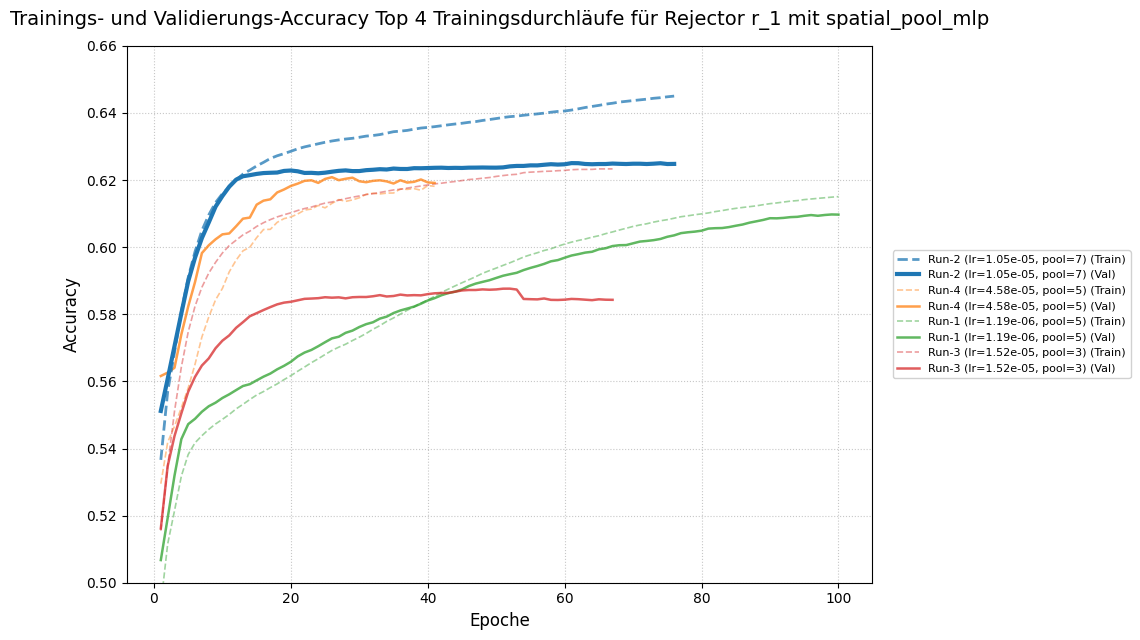


Ranking nach bester Validation Accuracy:
01. Run-2 (lr=1.05e-05, pool=7)    lr=1.05e-05 wd=0.00e+00 val_best=0.6250 train_final=0.6450
02. Run-4 (lr=4.58e-05, pool=5)    lr=4.58e-05 wd=0.00e+00 val_best=0.6209 train_final=0.6181
03. Run-1 (lr=1.19e-06, pool=5)    lr=1.19e-06 wd=0.00e+00 val_best=0.6097 train_final=0.6151
04. Run-3 (lr=1.52e-05, pool=3)    lr=1.52e-05 wd=0.00e+00 val_best=0.5876 train_final=0.6233


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Top 4 Trainingsdurchläufe für Rejector r_1 mit spatial_pool_mlp'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# TOP 4 REJECTOR RUNS (spatial_pool_mlp) - selected from tensorboard_runs_rejector-new-targets
# These runs were chosen because they contain Accuracy_train and Accuracy_val subfolders
# ==========================================
rejector_runs_embedding = {
    "Run-1 (lr=1.19e-06, pool=5)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new-targets/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr1.19e-06_wd0.00e+00_drop0.0_pool5_ptypeavg_hidden64_worker1_trial0",
        "lr": 1.19e-06,
        "wd": 0.0,
        "pool": 5,
    },
    "Run-2 (lr=1.05e-05, pool=7)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new-targets/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr1.05e-05_wd0.00e+00_drop0.0_pool7_ptypeavg_hidden64_worker2_trial3",
        "lr": 1.05e-05,
        "wd": 0.0,
        "pool": 7,
    },
    "Run-3 (lr=1.52e-05, pool=3)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new-targets/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr1.52e-05_wd0.00e+00_drop0.0_pool3_ptypemax_hidden64_worker0_trial1",
        "lr": 1.52e-05,
        "wd": 0.0,
        "pool": 3,
    },
    "Run-4 (lr=4.58e-05, pool=5)": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new-targets/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr4.58e-05_wd0.00e+00_drop0.2_pool5_ptypeavg_hidden64_worker2_trial6",
        "lr": 4.58e-05,
        "wd": 0.0,
        "pool": 5,
    },
}

plot_rejector_train_val(
    rejector_runs_embedding,
    model_name="Top 4 Trainingsdurchläufe für Rejector r_1 mit spatial_pool_mlp",
    save_path="rejector_spatial_pool_mlp_top4.pdf",
    highlight_best=True,
    ylim=(0.5, 0.66),
)


✅ Plot gespeich(ert unter: rejector_conv_mlp_top10.pdf


✅ Plot gespeich(ert unter: rejector_conv_mlp_top10.pdf


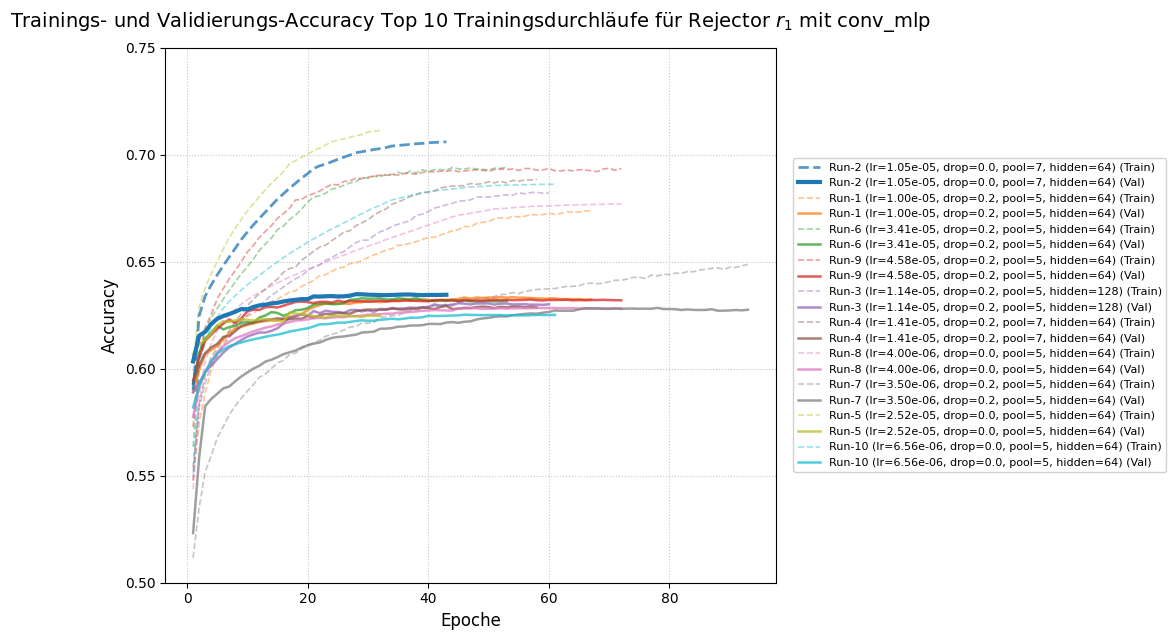


Ranking nach bester Validation Accuracy:
01. Run-2 (lr=1.05e-05, drop=0.0, pool=7, hidden=64) lr=1.05e-05 wd=0.00e+00 val_best=0.6348 train_final=0.7061
02. Run-1 (lr=1.00e-05, drop=0.2, pool=5, hidden=64) lr=1.00e-05 wd=0.00e+00 val_best=0.6336 train_final=0.6736
03. Run-6 (lr=3.41e-05, drop=0.2, pool=5, hidden=64) lr=3.41e-05 wd=0.00e+00 val_best=0.6330 train_final=0.6941
04. Run-9 (lr=4.58e-05, drop=0.2, pool=5, hidden=64) lr=4.58e-05 wd=0.00e+00 val_best=0.6324 train_final=0.6935
05. Run-3 (lr=1.14e-05, drop=0.2, pool=5, hidden=128) lr=1.14e-05 wd=0.00e+00 val_best=0.6307 train_final=0.6821
06. Run-4 (lr=1.41e-05, drop=0.2, pool=7, hidden=64) lr=1.41e-05 wd=0.00e+00 val_best=0.6294 train_final=0.6885
07. Run-8 (lr=4.00e-06, drop=0.0, pool=5, hidden=64) lr=4.00e-06 wd=0.00e+00 val_best=0.6285 train_final=0.6770
08. Run-7 (lr=3.50e-06, drop=0.2, pool=5, hidden=64) lr=3.50e-06 wd=0.00e+00 val_best=0.6285 train_final=0.6488
09. Run-5 (lr=2.52e-05, drop=0.0, pool=5, hidden=64) lr=2.52e

(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Top 10 Trainingsdurchläufe für Rejector $r_1$ mit conv_mlp'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# TOP 10 REJECTOR RUNS (conv_mlp)
# selected from tensorboard_runs_rejector-new-targets
# ==========================================

BASE_PATH = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new-targets"

rejector_runs_embedding = {
    "Run-1 (lr=1.00e-05, drop=0.2, pool=5, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr1.00e-05_wd0.00e+00_drop0.2_channels64_extraFalse_pool5_hidden64_worker3_trial6",
        "lr": 1.00e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 5,
        "hidden": 64,
    },
    "Run-2 (lr=1.05e-05, drop=0.0, pool=7, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr1.05e-05_wd0.00e+00_drop0.0_channels64_extraFalse_pool7_hidden64_worker2_trial3",
        "lr": 1.05e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 64,
        "pool": 7,
        "hidden": 64,
    },
    "Run-3 (lr=1.14e-05, drop=0.2, pool=5, hidden=128)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr1.14e-05_wd0.00e+00_drop0.2_channels64_extraFalse_pool5_hidden128_worker1_trial5",
        "lr": 1.14e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 5,
        "hidden": 128,
    },
    "Run-4 (lr=1.41e-05, drop=0.2, pool=7, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr1.41e-05_wd0.00e+00_drop0.2_channels64_extraFalse_pool7_hidden64_worker1_trial8",
        "lr": 1.41e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 7,
        "hidden": 64,
    },
    "Run-5 (lr=2.52e-05, drop=0.0, pool=5, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr2.52e-05_wd0.00e+00_drop0.0_channels64_extraFalse_pool5_hidden64_worker3_trial3",
        "lr": 2.52e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 64,
        "pool": 5,
        "hidden": 64,
    },
    "Run-6 (lr=3.41e-05, drop=0.2, pool=5, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr3.41e-05_wd0.00e+00_drop0.2_channels64_extraFalse_pool5_hidden64_worker2_trial2",
        "lr": 3.41e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 5,
        "hidden": 64,
    },
    "Run-7 (lr=3.50e-06, drop=0.2, pool=5, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr3.50e-06_wd0.00e+00_drop0.2_channels64_extraFalse_pool5_hidden64_worker3_trial0",
        "lr": 3.50e-06,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 5,
        "hidden": 64,
    },
    "Run-8 (lr=4.00e-06, drop=0.0, pool=5, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr4.00e-06_wd0.00e+00_drop0.0_channels64_extraFalse_pool5_hidden64_worker3_trial8",
        "lr": 4.00e-06,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 64,
        "pool": 5,
        "hidden": 64,
    },
    "Run-9 (lr=4.58e-05, drop=0.2, pool=5, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr4.58e-05_wd0.00e+00_drop0.2_channels64_extraFalse_pool5_hidden64_worker2_trial6",
        "lr": 4.58e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 5,
        "hidden": 64,
    },
    "Run-10 (lr=6.56e-06, drop=0.0, pool=5, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_3_GAP_conv_mlp_lr6.56e-06_wd0.00e+00_drop0.0_channels64_extraFalse_pool5_hidden64_worker2_trial0",
        "lr": 6.56e-06,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 64,
        "pool": 5,
        "hidden": 64,
    },
}

plot_rejector_train_val(
    rejector_runs_embedding,
    model_name="Top 10 Trainingsdurchläufe für Rejector $r_1$ mit conv_mlp",
    save_path="rejector_conv_mlp_top10.pdf",
    highlight_best=True,
    ylim=(0.5, 0.75),
)

✅ Plot gespeich(ert unter: rejector_spatial_pool_mlp_top10.pdf


✅ Plot gespeich(ert unter: rejector_spatial_pool_mlp_top10.pdf


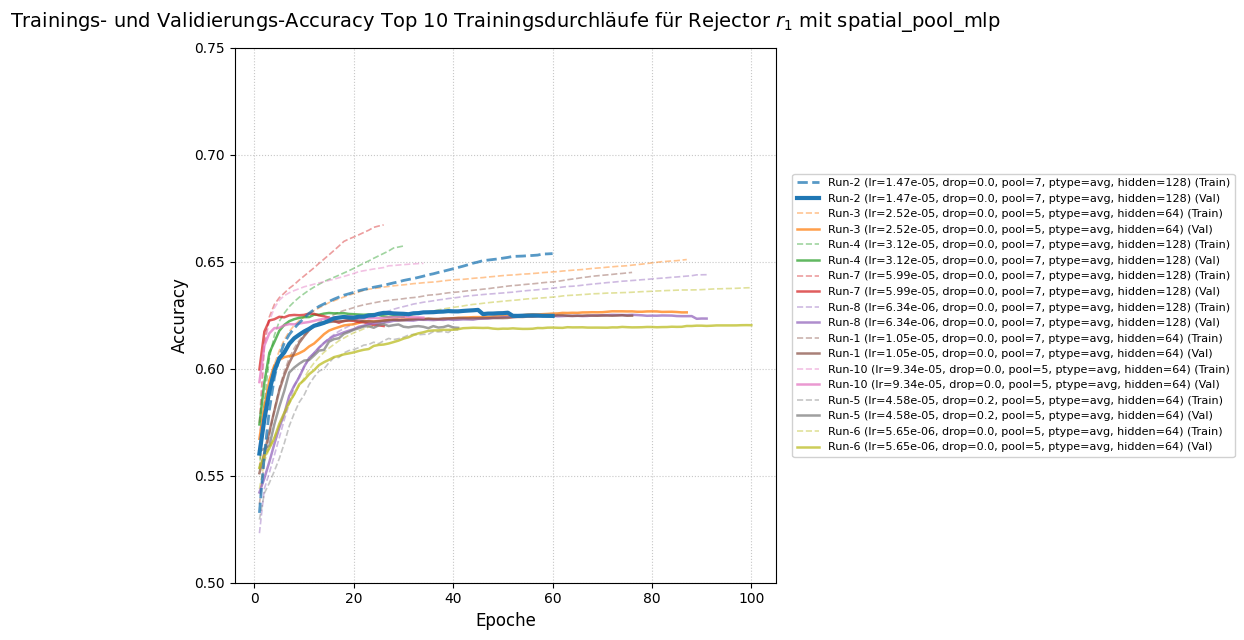


Ranking nach bester Validation Accuracy:
01. Run-2 (lr=1.47e-05, drop=0.0, pool=7, ptype=avg, hidden=128) lr=1.47e-05 wd=0.00e+00 val_best=0.6275 train_final=0.6538
02. Run-3 (lr=2.52e-05, drop=0.0, pool=5, ptype=avg, hidden=64) lr=2.52e-05 wd=0.00e+00 val_best=0.6269 train_final=0.6511
03. Run-4 (lr=3.12e-05, drop=0.0, pool=7, ptype=avg, hidden=128) lr=3.12e-05 wd=0.00e+00 val_best=0.6261 train_final=0.6574
04. Run-7 (lr=5.99e-05, drop=0.0, pool=7, ptype=avg, hidden=128) lr=5.99e-05 wd=0.00e+00 val_best=0.6258 train_final=0.6672
05. Run-8 (lr=6.34e-06, drop=0.0, pool=7, ptype=avg, hidden=128) lr=6.34e-06 wd=0.00e+00 val_best=0.6252 train_final=0.6440
06. Run-1 (lr=1.05e-05, drop=0.0, pool=7, ptype=avg, hidden=64) lr=1.05e-05 wd=0.00e+00 val_best=0.6250 train_final=0.6450
07. Run-10 (lr=9.34e-05, drop=0.0, pool=5, ptype=avg, hidden=64) lr=9.34e-05 wd=0.00e+00 val_best=0.6246 train_final=0.6493
08. Run-5 (lr=4.58e-05, drop=0.2, pool=5, ptype=avg, hidden=64) lr=4.58e-05 wd=0.00e+00 val_

(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Top 10 Trainingsdurchläufe für Rejector $r_1$ mit spatial_pool_mlp'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# TOP 10 REJECTOR RUNS (spatial_pool_mlp) - selected from tensorboard_runs_rejector-new-targets
# ==========================================

BASE_PATH = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new-targets"

rejector_runs_spatial_pool_mlp = {
    "Run-1 (lr=1.05e-05, drop=0.0, pool=7, ptype=avg, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr1.05e-05_wd0.00e+00_drop0.0_pool7_ptypeavg_hidden64_worker2_trial3",
        "lr": 1.05e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "pool": 7,
        "ptype": "avg",
        "hidden": 64,
    },
    "Run-2 (lr=1.47e-05, drop=0.0, pool=7, ptype=avg, hidden=128)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr1.47e-05_wd0.00e+00_drop0.0_pool7_ptypeavg_hidden128_worker3_trial7",
        "lr": 1.47e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "pool": 7,
        "ptype": "avg",
        "hidden": 128,
    },
    "Run-3 (lr=2.52e-05, drop=0.0, pool=5, ptype=avg, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr2.52e-05_wd0.00e+00_drop0.0_pool5_ptypeavg_hidden64_worker3_trial3",
        "lr": 2.52e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "pool": 5,
        "ptype": "avg",
        "hidden": 64,
    },
    "Run-4 (lr=3.12e-05, drop=0.0, pool=7, ptype=avg, hidden=128)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr3.12e-05_wd0.00e+00_drop0.0_pool7_ptypeavg_hidden128_worker2_trial5",
        "lr": 3.12e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "pool": 7,
        "ptype": "avg",
        "hidden": 128,
    },
    "Run-5 (lr=4.58e-05, drop=0.2, pool=5, ptype=avg, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr4.58e-05_wd0.00e+00_drop0.2_pool5_ptypeavg_hidden64_worker2_trial6",
        "lr": 4.58e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "pool": 5,
        "ptype": "avg",
        "hidden": 64,
    },
    "Run-6 (lr=5.65e-06, drop=0.0, pool=5, ptype=avg, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr5.65e-06_wd0.00e+00_drop0.0_pool5_ptypeavg_hidden64_worker1_trial2",
        "lr": 5.65e-06,
        "wd": 0.0,
        "dropout": 0.0,
        "pool": 5,
        "ptype": "avg",
        "hidden": 64,
    },
    "Run-7 (lr=5.99e-05, drop=0.0, pool=7, ptype=avg, hidden=128)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr5.99e-05_wd0.00e+00_drop0.0_pool7_ptypeavg_hidden128_worker1_trial4",
        "lr": 5.99e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "pool": 7,
        "ptype": "avg",
        "hidden": 128,
    },
    "Run-8 (lr=6.34e-06, drop=0.0, pool=7, ptype=avg, hidden=128)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr6.34e-06_wd0.00e+00_drop0.0_pool7_ptypeavg_hidden128_worker0_trial9",
        "lr": 6.34e-06,
        "wd": 0.0,
        "dropout": 0.0,
        "pool": 7,
        "ptype": "avg",
        "hidden": 128,
    },
    "Run-9 (lr=6.56e-06, drop=0.0, pool=7, ptype=avg, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr6.56e-06_wd0.00e+00_drop0.0_pool7_ptypeavg_hidden64_worker3_trial4",
        "lr": 6.56e-06,
        "wd": 0.0,
        "dropout": 0.0,
        "pool": 7,
        "ptype": "avg",
        "hidden": 64,
    },
    "Run-10 (lr=9.34e-05, drop=0.0, pool=5, ptype=avg, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/spatial_pool_mlp/run_embedding_3_GAP_spatial_pool_mlp_lr9.34e-05_wd0.00e+00_drop0.0_pool5_ptypeavg_hidden64_worker0_trial6",
        "lr": 9.34e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "pool": 5,
        "ptype": "avg",
        "hidden": 64,
    },
}

plot_rejector_train_val(
    rejector_runs_spatial_pool_mlp,
    model_name="Top 10 Trainingsdurchläufe für Rejector $r_1$ mit spatial_pool_mlp",
    save_path="rejector_spatial_pool_mlp_top10.pdf",
    highlight_best=True,
    ylim=(0.5, 0.75),
)

✅ Plot gespeich(ert unter: rejector_pooled_mlp_top10.pdf


✅ Plot gespeich(ert unter: rejector_pooled_mlp_top10.pdf


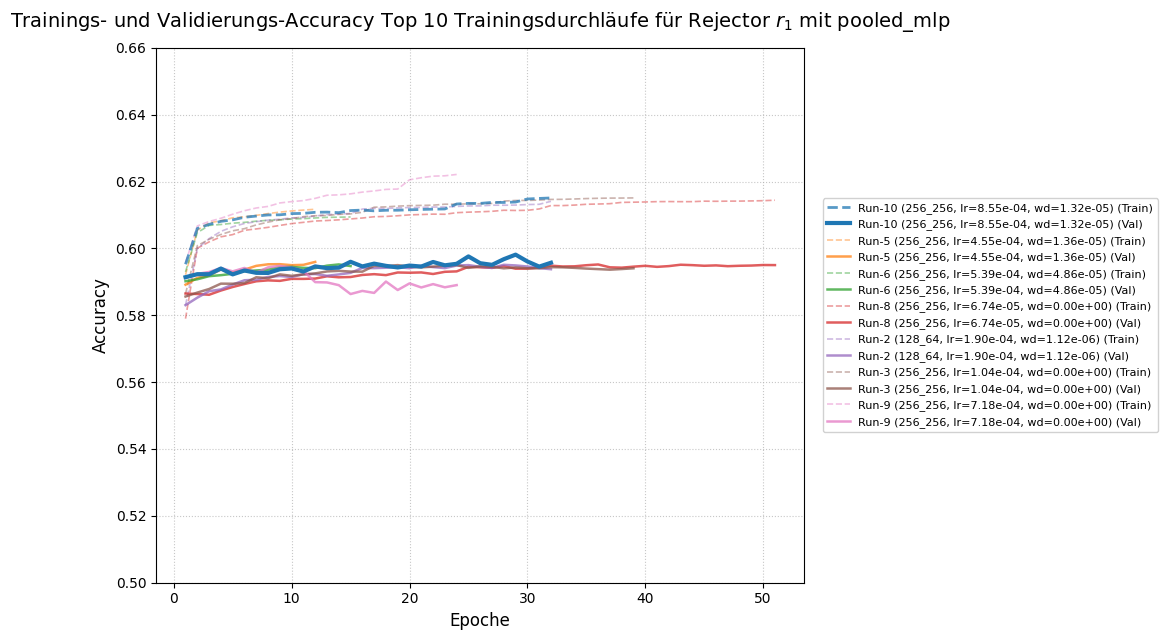


Ranking nach bester Validation Accuracy:
01. Run-10 (256_256, lr=8.55e-04, wd=1.32e-05) lr=8.55e-04 wd=1.32e-05 val_best=0.5981 train_final=0.6151
02. Run-5 (256_256, lr=4.55e-04, wd=1.36e-05) lr=4.55e-04 wd=1.36e-05 val_best=0.5960 train_final=0.6117
03. Run-6 (256_256, lr=5.39e-04, wd=4.86e-05) lr=5.39e-04 wd=4.86e-05 val_best=0.5952 train_final=0.6094
04. Run-8 (256_256, lr=6.74e-05, wd=0.00e+00) lr=6.74e-05 wd=0.00e+00 val_best=0.5952 train_final=0.6144
05. Run-2 (128_64, lr=1.90e-04, wd=1.12e-06) lr=1.90e-04 wd=1.12e-06 val_best=0.5951 train_final=0.6141
06. Run-3 (256_256, lr=1.04e-04, wd=0.00e+00) lr=1.04e-04 wd=0.00e+00 val_best=0.5950 train_final=0.6151
07. Run-9 (256_256, lr=7.18e-04, wd=0.00e+00) lr=7.18e-04 wd=0.00e+00 val_best=0.5948 train_final=0.6221


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Top 10 Trainingsdurchläufe für Rejector $r_1$ mit pooled_mlp'}, xlabel='Epoche', ylabel='Accuracy'>)

✅ Plot gespeich(ert unter: rejector_pooled_mlp_top10.pdf


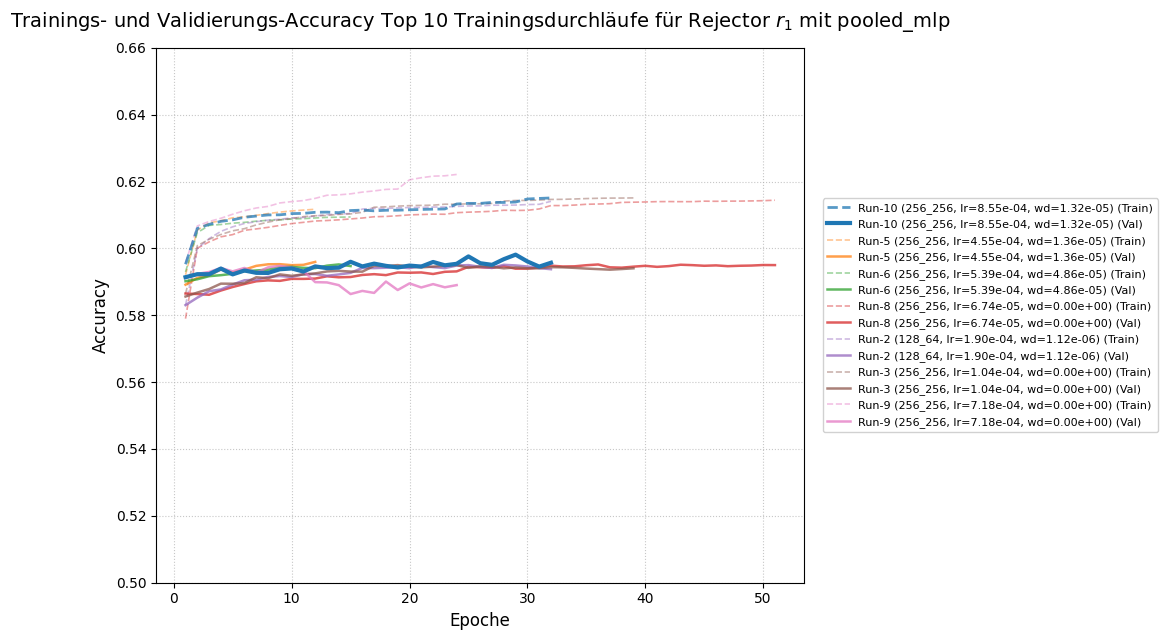


Ranking nach bester Validation Accuracy:
01. Run-10 (256_256, lr=8.55e-04, wd=1.32e-05) lr=8.55e-04 wd=1.32e-05 val_best=0.5981 train_final=0.6151
02. Run-5 (256_256, lr=4.55e-04, wd=1.36e-05) lr=4.55e-04 wd=1.36e-05 val_best=0.5960 train_final=0.6117
03. Run-6 (256_256, lr=5.39e-04, wd=4.86e-05) lr=5.39e-04 wd=4.86e-05 val_best=0.5952 train_final=0.6094
04. Run-8 (256_256, lr=6.74e-05, wd=0.00e+00) lr=6.74e-05 wd=0.00e+00 val_best=0.5952 train_final=0.6144
05. Run-2 (128_64, lr=1.90e-04, wd=1.12e-06) lr=1.90e-04 wd=1.12e-06 val_best=0.5951 train_final=0.6141
06. Run-3 (256_256, lr=1.04e-04, wd=0.00e+00) lr=1.04e-04 wd=0.00e+00 val_best=0.5950 train_final=0.6151
07. Run-9 (256_256, lr=7.18e-04, wd=0.00e+00) lr=7.18e-04 wd=0.00e+00 val_best=0.5948 train_final=0.6221


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Top 10 Trainingsdurchläufe für Rejector $r_1$ mit pooled_mlp'}, xlabel='Epoche', ylabel='Accuracy'>)

: 

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# TOP 10 REJECTOR RUNS (pooled_mlp) - selected from tensorboard_runs_rejector-new-targets
# ==========================================

BASE_PATH = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new-targets"

rejector_runs_pooled_mlp = {
    "Run-1 (128_64, lr=2.52e-04, wd=1.84e-06)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_128_64/run_embedding_3_GAP_pooled_mlp_128_64_lr2.52e-04_wd1.84e-06_drop0.0_hidden128_64_worker6_trial0",
        "lr": 2.52e-04,
        "wd": 1.84e-06,
        "hidden": "128_64",
    },
    "Run-2 (128_64, lr=1.90e-04, wd=1.12e-06)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_128_64/run_embedding_3_GAP_pooled_mlp_128_64_lr1.90e-04_wd1.12e-06_drop0.0_hidden128_64_worker0_trial0",
        "lr": 1.90e-04,
        "wd": 1.12e-06,
        "hidden": "128_64",
    },
    "Run-3 (256_256, lr=1.04e-04, wd=0.00e+00)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_256_256/run_embedding_3_GAP_pooled_mlp_256_256_lr1.04e-04_wd0.00e+00_drop0.0_hidden256_256_worker20_trial1",
        "lr": 1.04e-04,
        "wd": 0.0,
        "hidden": "256_256",
    },
    "Run-4 (256_256, lr=1.75e-04, wd=0.00e+00)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_256_256/run_embedding_3_GAP_pooled_mlp_256_256_lr1.75e-04_wd0.00e+00_drop0.0_hidden256_256_worker17_trial0",
        "lr": 1.75e-04,
        "wd": 0.0,
        "hidden": "256_256",
    },
    "Run-5 (256_256, lr=4.55e-04, wd=1.36e-05)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_256_256/run_embedding_3_GAP_pooled_mlp_256_256_lr4.55e-04_wd1.36e-05_drop0.0_hidden256_256_worker27_trial1",
        "lr": 4.55e-04,
        "wd": 1.36e-05,
        "hidden": "256_256",
    },
    "Run-6 (256_256, lr=5.39e-04, wd=4.86e-05)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_256_256/run_embedding_3_GAP_pooled_mlp_256_256_lr5.39e-04_wd4.86e-05_drop0.0_hidden256_256_worker24_trial1",
        "lr": 5.39e-04,
        "wd": 4.86e-05,
        "hidden": "256_256",
    },
    "Run-7 (256_256, lr=6.60e-04, wd=3.87e-06)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_256_256/run_embedding_3_GAP_pooled_mlp_256_256_lr6.60e-04_wd3.87e-06_drop0.0_hidden256_256_worker28_trial1",
        "lr": 6.60e-04,
        "wd": 3.87e-06,
        "hidden": "256_256",
    },
    "Run-8 (256_256, lr=6.74e-05, wd=0.00e+00)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_256_256/run_embedding_3_GAP_pooled_mlp_256_256_lr6.74e-05_wd0.00e+00_drop0.0_hidden256_256_worker27_trial2",
        "lr": 6.74e-05,
        "wd": 0.0,
        "hidden": "256_256",
    },
    "Run-9 (256_256, lr=7.18e-04, wd=0.00e+00)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_256_256/run_embedding_3_GAP_pooled_mlp_256_256_lr7.18e-04_wd0.00e+00_drop0.0_hidden256_256_worker20_trial0",
        "lr": 7.18e-04,
        "wd": 0.0,
        "hidden": "256_256",
    },
    "Run-10 (256_256, lr=8.55e-04, wd=1.32e-05)": {
        "path": f"{BASE_PATH}/embedding/pooled_mlp_256_256/run_embedding_3_GAP_pooled_mlp_256_256_lr8.55e-04_wd1.32e-05_drop0.0_hidden256_256_worker14_trial0",
        "lr": 8.55e-04,
        "wd": 1.32e-05,
        "hidden": "256_256",
    },
}

plot_rejector_train_val(
    rejector_runs_pooled_mlp,
    model_name="Top 10 Trainingsdurchläufe für Rejector $r_1$ mit pooled_mlp",
    save_path="rejector_pooled_mlp_top10.pdf",
    highlight_best=True,
    ylim=(0.5, 0.66),
)

✅ Plot gespeich(ert unter: rejector_conv_gap_top10.pdf


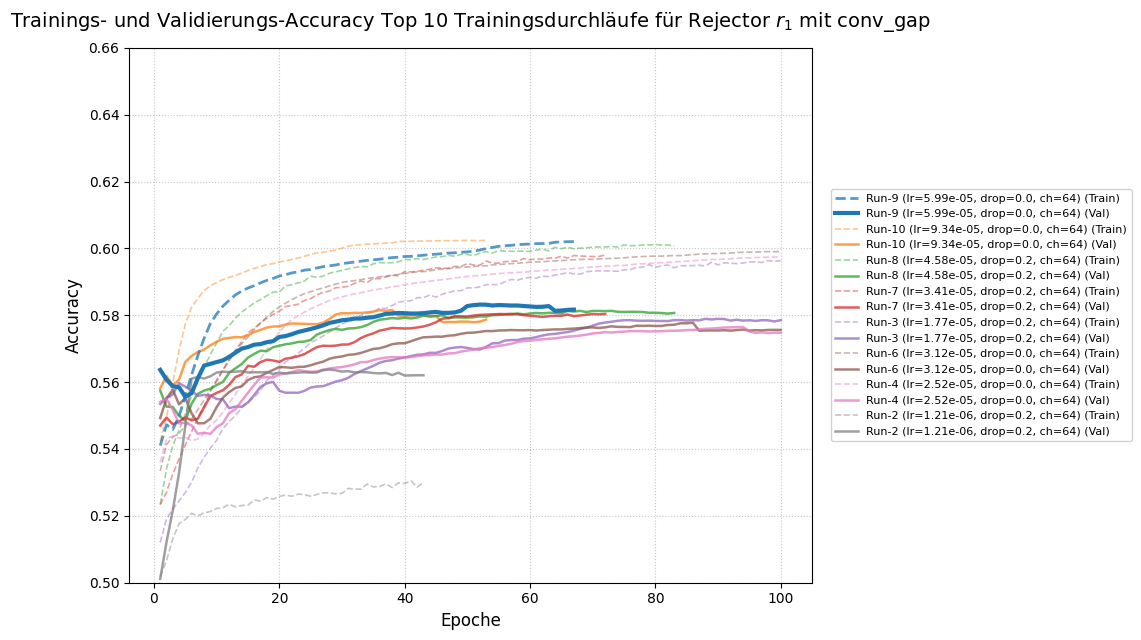


Ranking nach bester Validation Accuracy:
01. Run-9 (lr=5.99e-05, drop=0.0, ch=64) lr=5.99e-05 wd=0.00e+00 val_best=0.5832 train_final=0.6020
02. Run-10 (lr=9.34e-05, drop=0.0, ch=64) lr=9.34e-05 wd=0.00e+00 val_best=0.5816 train_final=0.6024
03. Run-8 (lr=4.58e-05, drop=0.2, ch=64) lr=4.58e-05 wd=0.00e+00 val_best=0.5813 train_final=0.6007
04. Run-7 (lr=3.41e-05, drop=0.2, ch=64) lr=3.41e-05 wd=0.00e+00 val_best=0.5804 train_final=0.5980
05. Run-3 (lr=1.77e-05, drop=0.2, ch=64) lr=1.77e-05 wd=0.00e+00 val_best=0.5789 train_final=0.5963
06. Run-6 (lr=3.12e-05, drop=0.0, ch=64) lr=3.12e-05 wd=0.00e+00 val_best=0.5778 train_final=0.5991
07. Run-4 (lr=2.52e-05, drop=0.0, ch=64) lr=2.52e-05 wd=0.00e+00 val_best=0.5765 train_final=0.5974
08. Run-2 (lr=1.21e-06, drop=0.2, ch=64) lr=1.21e-06 wd=0.00e+00 val_best=0.5638 train_final=0.5300


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Top 10 Trainingsdurchläufe für Rejector $r_1$ mit conv_gap'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# TOP 10 REJECTOR RUNS (conv_gap) - selected from tensorboard_runs_rejector-new-targets
# ==========================================

BASE_PATH = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector-new-targets"

rejector_runs_conv_gap = {
    "Run-1 (lr=1.19e-06, drop=0.2, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr1.19e-06_wd0.00e+00_drop0.2_channels64_extraFalse_worker1_trial0",
        "lr": 1.19e-06,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
    },
    "Run-2 (lr=1.21e-06, drop=0.2, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr1.21e-06_wd0.00e+00_drop0.2_channels64_extraFalse_worker1_trial7",
        "lr": 1.21e-06,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
    },
    "Run-3 (lr=1.77e-05, drop=0.2, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr1.77e-05_wd0.00e+00_drop0.2_channels64_extraFalse_worker3_trial9",
        "lr": 1.77e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
    },
    "Run-4 (lr=2.52e-05, drop=0.0, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr2.52e-05_wd0.00e+00_drop0.0_channels64_extraFalse_worker3_trial3",
        "lr": 2.52e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 64,
    },
    "Run-5 (lr=2.70e-05, drop=0.0, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr2.70e-05_wd0.00e+00_drop0.0_channels64_extraFalse_worker0_trial2",
        "lr": 2.70e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 64,
    },
    "Run-6 (lr=3.12e-05, drop=0.0, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr3.12e-05_wd0.00e+00_drop0.0_channels64_extraFalse_worker2_trial5",
        "lr": 3.12e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 64,
    },
    "Run-7 (lr=3.41e-05, drop=0.2, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr3.41e-05_wd0.00e+00_drop0.2_channels64_extraFalse_worker2_trial2",
        "lr": 3.41e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
    },
    "Run-8 (lr=4.58e-05, drop=0.2, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr4.58e-05_wd0.00e+00_drop0.2_channels64_extraFalse_worker2_trial6",
        "lr": 4.58e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
    },
    "Run-9 (lr=5.99e-05, drop=0.0, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr5.99e-05_wd0.00e+00_drop0.0_channels64_extraFalse_worker1_trial4",
        "lr": 5.99e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 64,
    },
    "Run-10 (lr=9.34e-05, drop=0.0, ch=64)": {
        "path": f"{BASE_PATH}/embedding/conv_gap/run_embedding_3_GAP_conv_gap_lr9.34e-05_wd0.00e+00_drop0.0_channels64_extraFalse_worker0_trial6",
        "lr": 9.34e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 64,
    },
}

plot_rejector_train_val(
    rejector_runs_conv_gap,
    model_name="Top 10 Trainingsdurchläufe für Rejector $r_1$ mit conv_gap",
    save_path="rejector_conv_gap_top10.pdf",
    highlight_best=True,
    ylim=(0.5, 0.66),
)

# r2

✅ Plot gespeich(ert unter: rejector_r2_resnet_small_top10.pdf


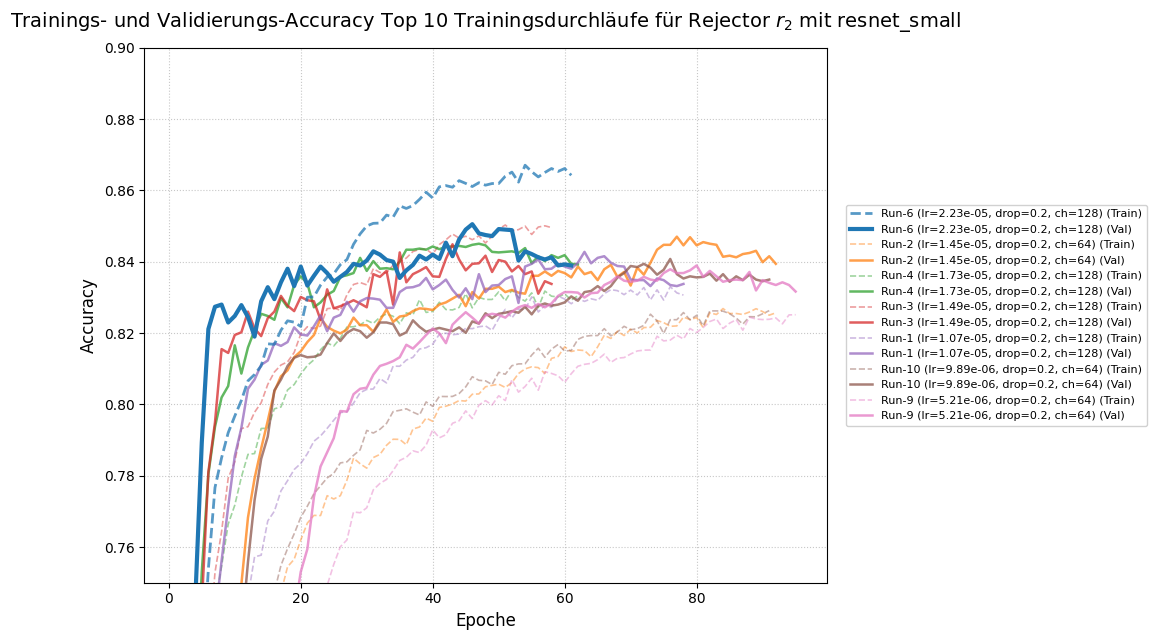


Ranking nach bester Validation Accuracy:
01. Run-6 (lr=2.23e-05, drop=0.2, ch=128) lr=2.23e-05 wd=0.00e+00 val_best=0.8505 train_final=0.8643
02. Run-2 (lr=1.45e-05, drop=0.2, ch=64) lr=1.45e-05 wd=0.00e+00 val_best=0.8470 train_final=0.8257
03. Run-4 (lr=1.73e-05, drop=0.2, ch=128) lr=1.73e-05 wd=0.00e+00 val_best=0.8451 train_final=0.8305
04. Run-3 (lr=1.49e-05, drop=0.2, ch=128) lr=1.49e-05 wd=0.00e+00 val_best=0.8449 train_final=0.8496
05. Run-1 (lr=1.07e-05, drop=0.2, ch=128) lr=1.07e-05 wd=0.00e+00 val_best=0.8428 train_final=0.8307
06. Run-10 (lr=9.89e-06, drop=0.2, ch=64) lr=9.89e-06 wd=0.00e+00 val_best=0.8408 train_final=0.8263
07. Run-9 (lr=5.21e-06, drop=0.2, ch=64) lr=5.21e-06 wd=0.00e+00 val_best=0.8390 train_final=0.8251


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Top 10 Trainingsdurchläufe für Rejector $r_2$ mit resnet_small'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# TOP 10 REJECTOR RUNS r_2 (resnet_small) - selected from tensorboard_runs_rejector_r2
# ==========================================

BASE_PATH = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector_r2"

rejector_runs_resnet_small = {
    "Run-1 (lr=1.07e-05, drop=0.2, ch=128)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr1.07e-05_wd0.00e+00_drop0.2_channels128_extraFalse_worker1_trial1",
        "lr": 1.07e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
    },
    "Run-2 (lr=1.45e-05, drop=0.2, ch=64)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr1.45e-05_wd0.00e+00_drop0.2_channels64_extraTrue_worker2_trial7",
        "lr": 1.45e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
    },
    "Run-3 (lr=1.49e-05, drop=0.2, ch=128)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr1.49e-05_wd0.00e+00_drop0.2_channels128_extraTrue_worker9_trial1",
        "lr": 1.49e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
    },
    "Run-4 (lr=1.73e-05, drop=0.2, ch=128)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr1.73e-05_wd0.00e+00_drop0.2_channels128_extraFalse_worker2_trial9",
        "lr": 1.73e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
    },
    "Run-5 (lr=1.77e-05, drop=0.2, ch=128)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr1.77e-05_wd0.00e+00_drop0.2_channels128_extraFalse_worker3_trial3",
        "lr": 1.77e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
    },
    "Run-6 (lr=2.23e-05, drop=0.2, ch=128)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr2.23e-05_wd0.00e+00_drop0.2_channels128_extraTrue_worker2_trial5",
        "lr": 2.23e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
    },
    "Run-7 (lr=2.70e-05, drop=0.2, ch=128)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr2.70e-05_wd0.00e+00_drop0.2_channels128_extraFalse_worker3_trial2",
        "lr": 2.70e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
    },
    "Run-8 (lr=2.95e-05, drop=0.0, ch=128)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr2.95e-05_wd0.00e+00_drop0.0_channels128_extraTrue_worker1_trial9",
        "lr": 2.95e-05,
        "wd": 0.0,
        "dropout": 0.0,
        "channels": 128,
    },
    "Run-9 (lr=5.21e-06, drop=0.2, ch=64)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr5.21e-06_wd0.00e+00_drop0.2_channels64_extraFalse_worker2_trial2",
        "lr": 5.21e-06,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
    },
    "Run-10 (lr=9.89e-06, drop=0.2, ch=64)": {
        "path": f"{BASE_PATH}/embedding/resnet_small/run_embedding_r2_resnet_small_lr9.89e-06_wd0.00e+00_drop0.2_channels64_extraTrue_worker8_trial0",
        "lr": 9.89e-06,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
    },
}

plot_rejector_train_val(
    rejector_runs_resnet_small,
    model_name="Top 10 Trainingsdurchläufe für Rejector $r_2$ mit resnet_small",
    save_path="rejector_r2_resnet_small_top10.pdf",
    highlight_best=True,
    ylim=(0.75, 0.9),
)

✅ Plot gespeich(ert unter: rejector_r2_conv_mlp_top10.pdf


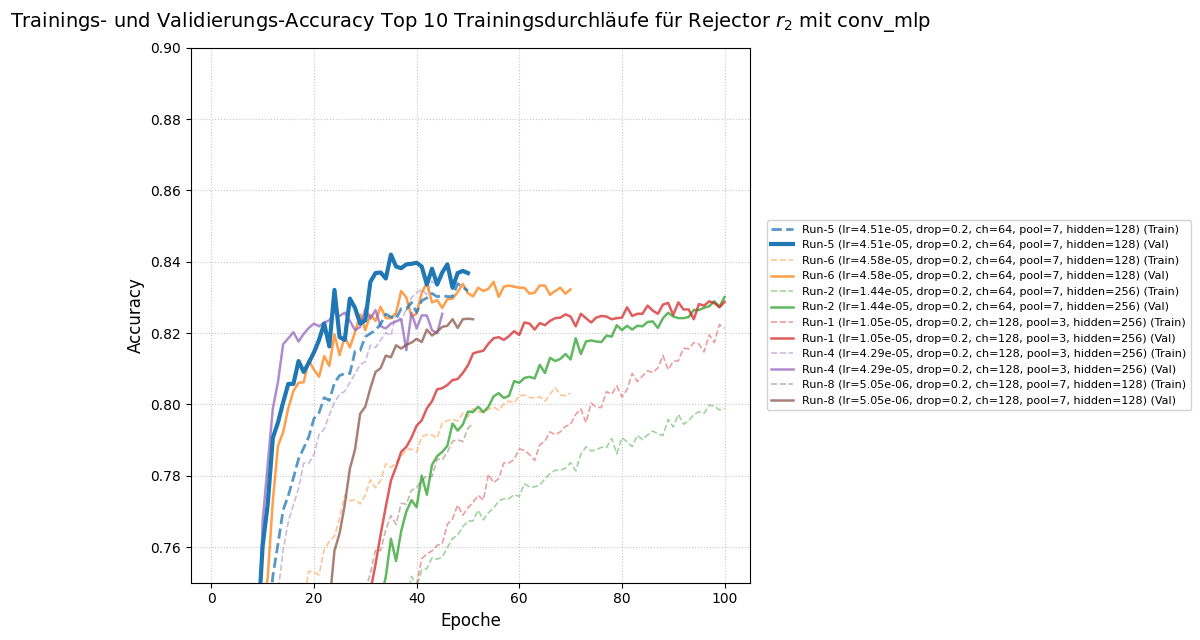


Ranking nach bester Validation Accuracy:
01. Run-5 (lr=4.51e-05, drop=0.2, ch=64, pool=7, hidden=128) lr=4.51e-05 wd=0.00e+00 val_best=0.8420 train_final=0.8318
02. Run-6 (lr=4.58e-05, drop=0.2, ch=64, pool=7, hidden=128) lr=4.58e-05 wd=0.00e+00 val_best=0.8344 train_final=0.8032
03. Run-2 (lr=1.44e-05, drop=0.2, ch=64, pool=7, hidden=256) lr=1.44e-05 wd=0.00e+00 val_best=0.8301 train_final=0.7989
04. Run-1 (lr=1.05e-05, drop=0.2, ch=128, pool=3, hidden=256) lr=1.05e-05 wd=0.00e+00 val_best=0.8289 train_final=0.8213
05. Run-4 (lr=4.29e-05, drop=0.2, ch=128, pool=3, hidden=256) lr=4.29e-05 wd=0.00e+00 val_best=0.8268 train_final=0.8359
06. Run-8 (lr=5.05e-06, drop=0.2, ch=128, pool=7, hidden=128) lr=5.05e-06 wd=0.00e+00 val_best=0.8240 train_final=0.7947


(<Figure size 1100x650 with 1 Axes>,
 <Axes: title={'center': 'Trainings- und Validierungs-Accuracy Top 10 Trainingsdurchläufe für Rejector $r_2$ mit conv_mlp'}, xlabel='Epoche', ylabel='Accuracy'>)

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ==========================================
# TOP 10 REJECTOR RUNS r_2 (conv_mlp) - selected from tensorboard_runs_rejector_r2
# ==========================================

BASE_PATH = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_rejector_r2"

rejector_runs_conv_mlp_r2 = {
    "Run-1 (lr=1.05e-05, drop=0.2, ch=128, pool=3, hidden=256)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr1.05e-05_wd0.00e+00_drop0.2_channels128_extraTrue_pool3_hidden256_worker11_trial3",
        "lr": 1.05e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
        "pool": 3,
        "hidden": 256,
    },
    "Run-2 (lr=1.44e-05, drop=0.2, ch=64, pool=7, hidden=256)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr1.44e-05_wd0.00e+00_drop0.2_channels64_extraFalse_pool7_hidden256_worker12_trial5",
        "lr": 1.44e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 7,
        "hidden": 256,
    },
    "Run-3 (lr=4.23e-05, drop=0.2, ch=128, pool=3, hidden=128)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr4.23e-05_wd0.00e+00_drop0.2_channels128_extraTrue_pool3_hidden128_worker12_trial6",
        "lr": 4.23e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
        "pool": 3,
        "hidden": 128,
    },
    "Run-4 (lr=4.29e-05, drop=0.2, ch=128, pool=3, hidden=256)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr4.29e-05_wd0.00e+00_drop0.2_channels128_extraTrue_pool3_hidden256_worker13_trial7",
        "lr": 4.29e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
        "pool": 3,
        "hidden": 256,
    },
    "Run-5 (lr=4.51e-05, drop=0.2, ch=64, pool=7, hidden=128)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr4.51e-05_wd0.00e+00_drop0.2_channels64_extraTrue_pool7_hidden128_worker13_trial6",
        "lr": 4.51e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 7,
        "hidden": 128,
    },
    "Run-6 (lr=4.58e-05, drop=0.2, ch=64, pool=7, hidden=128)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr4.58e-05_wd0.00e+00_drop0.2_channels64_extraFalse_pool7_hidden128_worker10_trial1",
        "lr": 4.58e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 7,
        "hidden": 128,
    },
    "Run-7 (lr=5.05e-06, drop=0.2, ch=128, pool=3, hidden=256)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr5.05e-06_wd0.00e+00_drop0.2_channels128_extraTrue_pool3_hidden256_worker13_trial1",
        "lr": 5.05e-06,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
        "pool": 3,
        "hidden": 256,
    },
    "Run-8 (lr=5.05e-06, drop=0.2, ch=128, pool=7, hidden=128)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr5.05e-06_wd0.00e+00_drop0.2_channels128_extraTrue_pool7_hidden128_worker5_trial0",
        "lr": 5.05e-06,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 128,
        "pool": 7,
        "hidden": 128,
    },
    "Run-9 (lr=5.98e-05, drop=0.2, ch=64, pool=5, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr5.98e-05_wd0.00e+00_drop0.2_channels64_extraFalse_pool5_hidden64_worker4_trial0",
        "lr": 5.98e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 5,
        "hidden": 64,
    },
    "Run-10 (lr=6.83e-05, drop=0.2, ch=64, pool=5, hidden=64)": {
        "path": f"{BASE_PATH}/embedding/conv_mlp/run_embedding_r2_conv_mlp_lr6.83e-05_wd0.00e+00_drop0.2_channels64_extraFalse_pool5_hidden64_worker11_trial6",
        "lr": 6.83e-05,
        "wd": 0.0,
        "dropout": 0.2,
        "channels": 64,
        "pool": 5,
        "hidden": 64,
    },
}

plot_rejector_train_val(
    rejector_runs_conv_mlp_r2,
    model_name="Top 10 Trainingsdurchläufe für Rejector $r_2$ mit conv_mlp",
    save_path="rejector_r2_conv_mlp_top10.pdf",
    highlight_best=True,
    ylim=(0.75, 0.9),
)

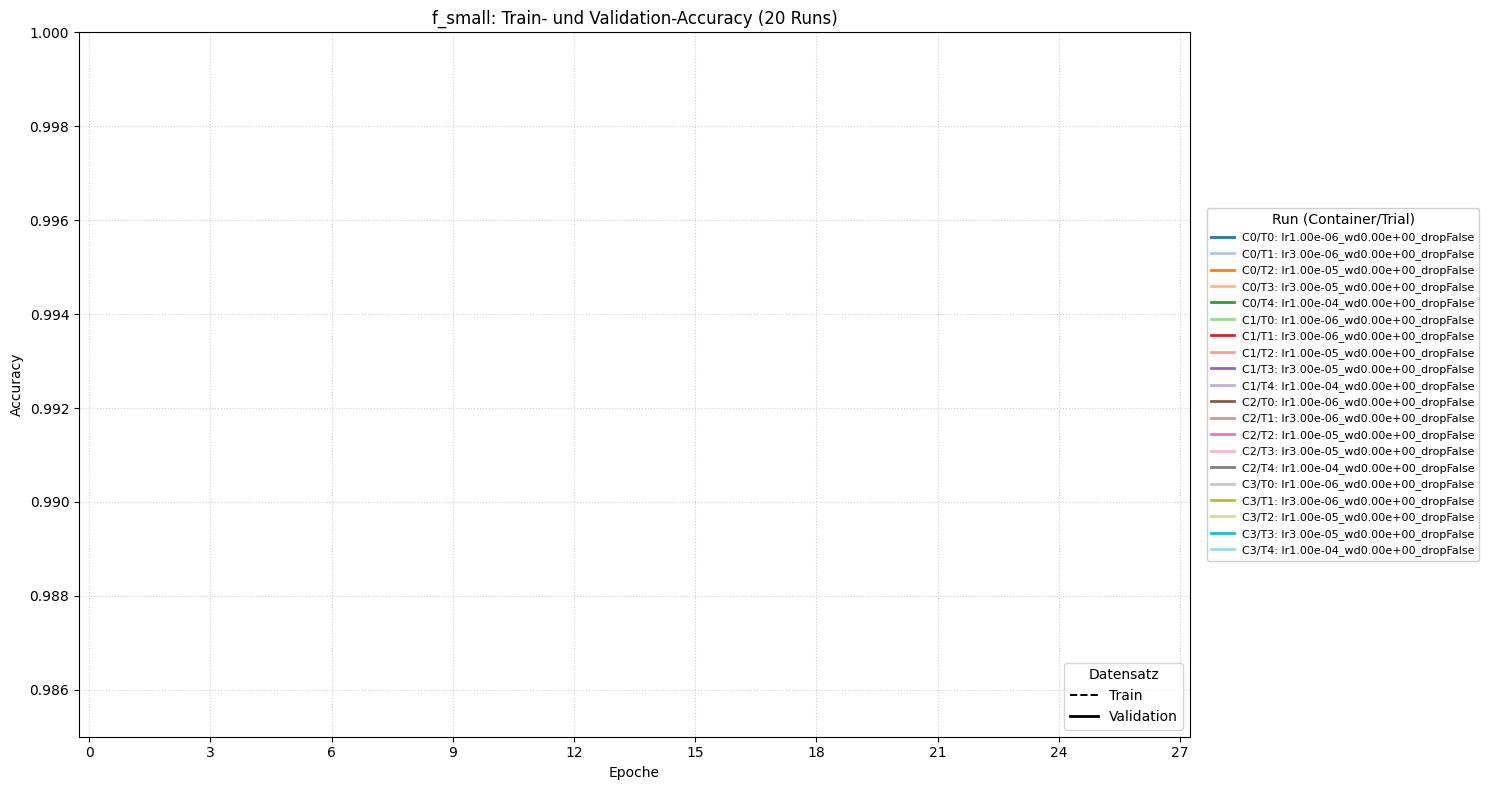

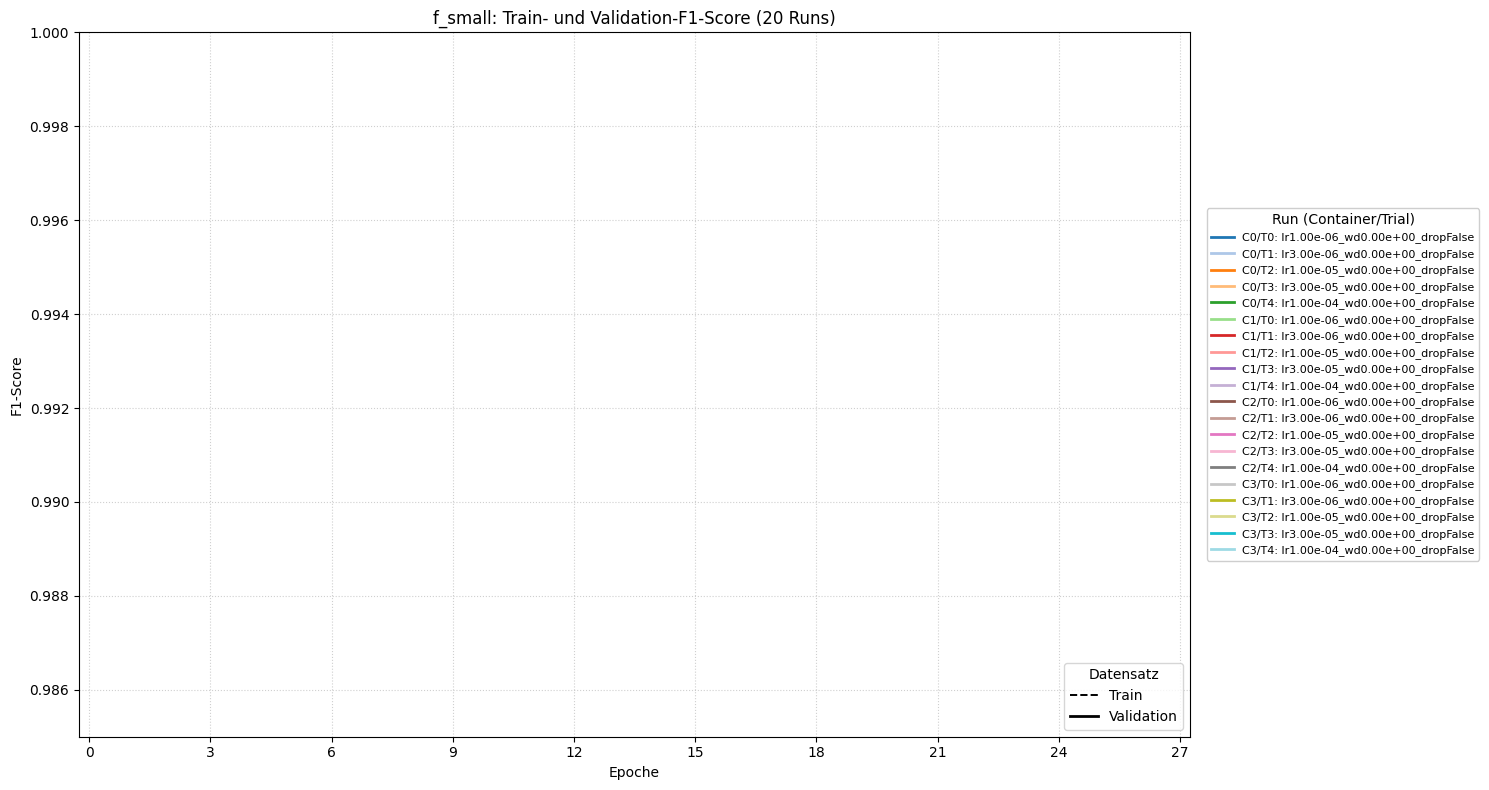

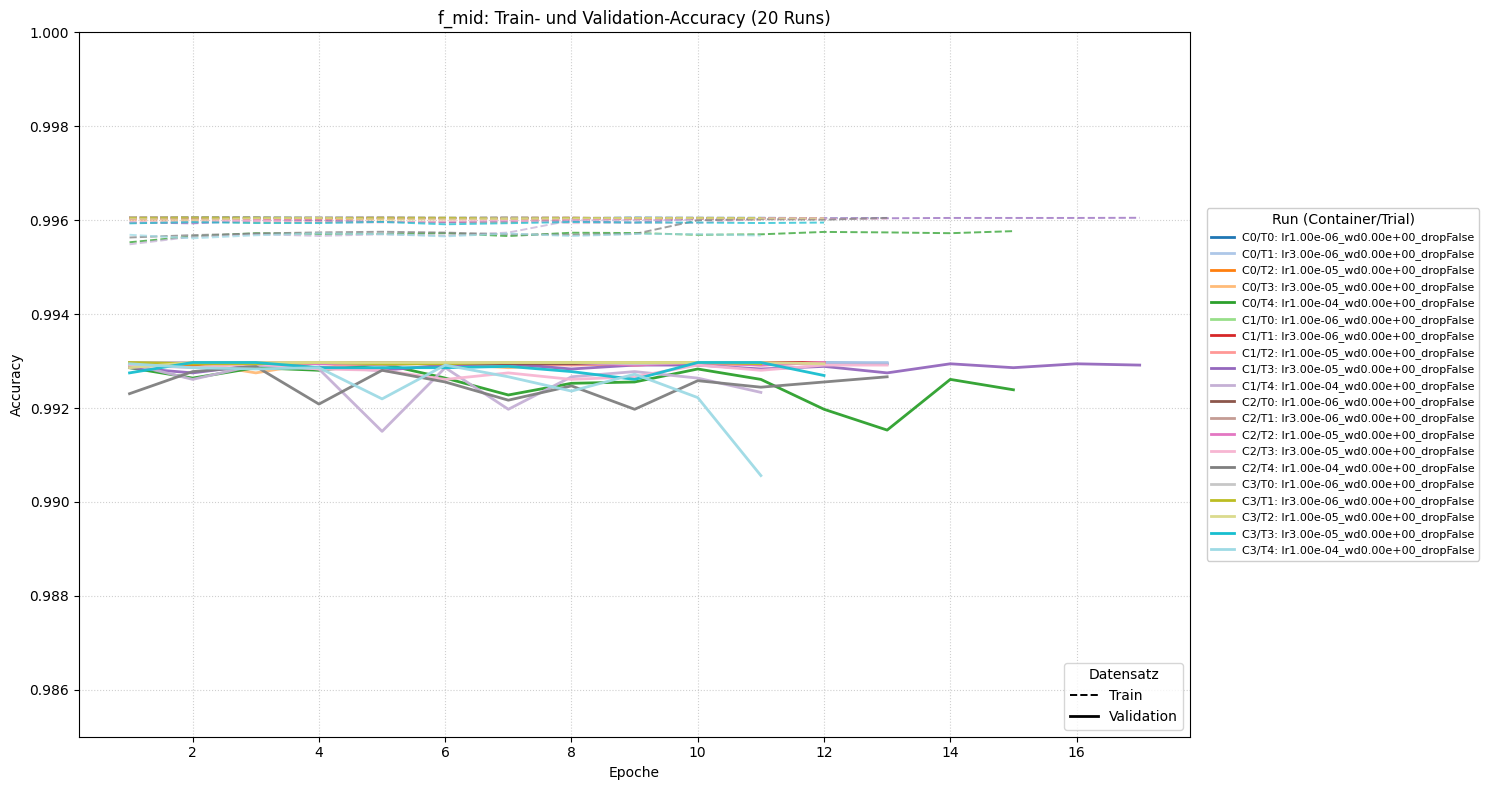

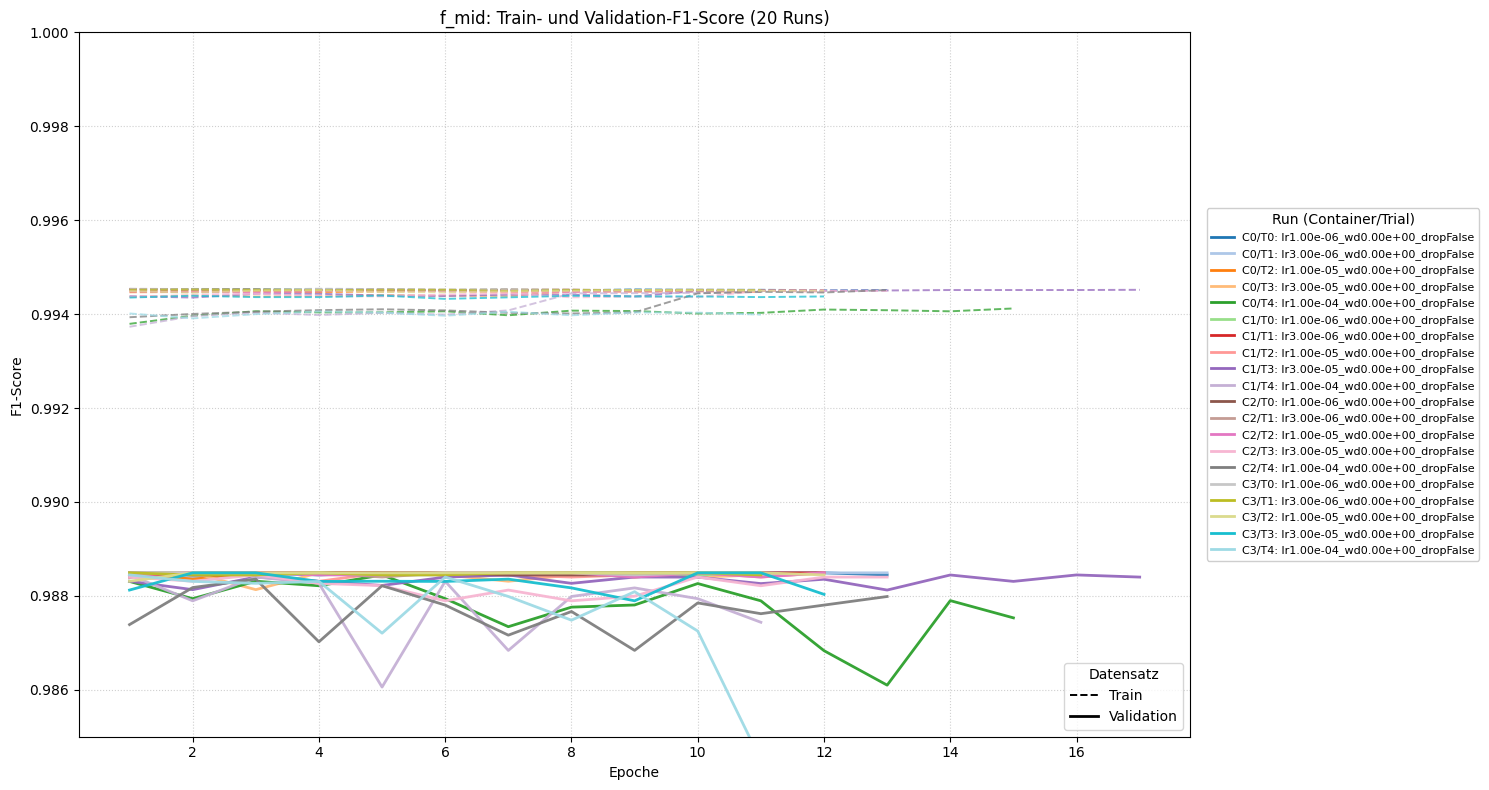

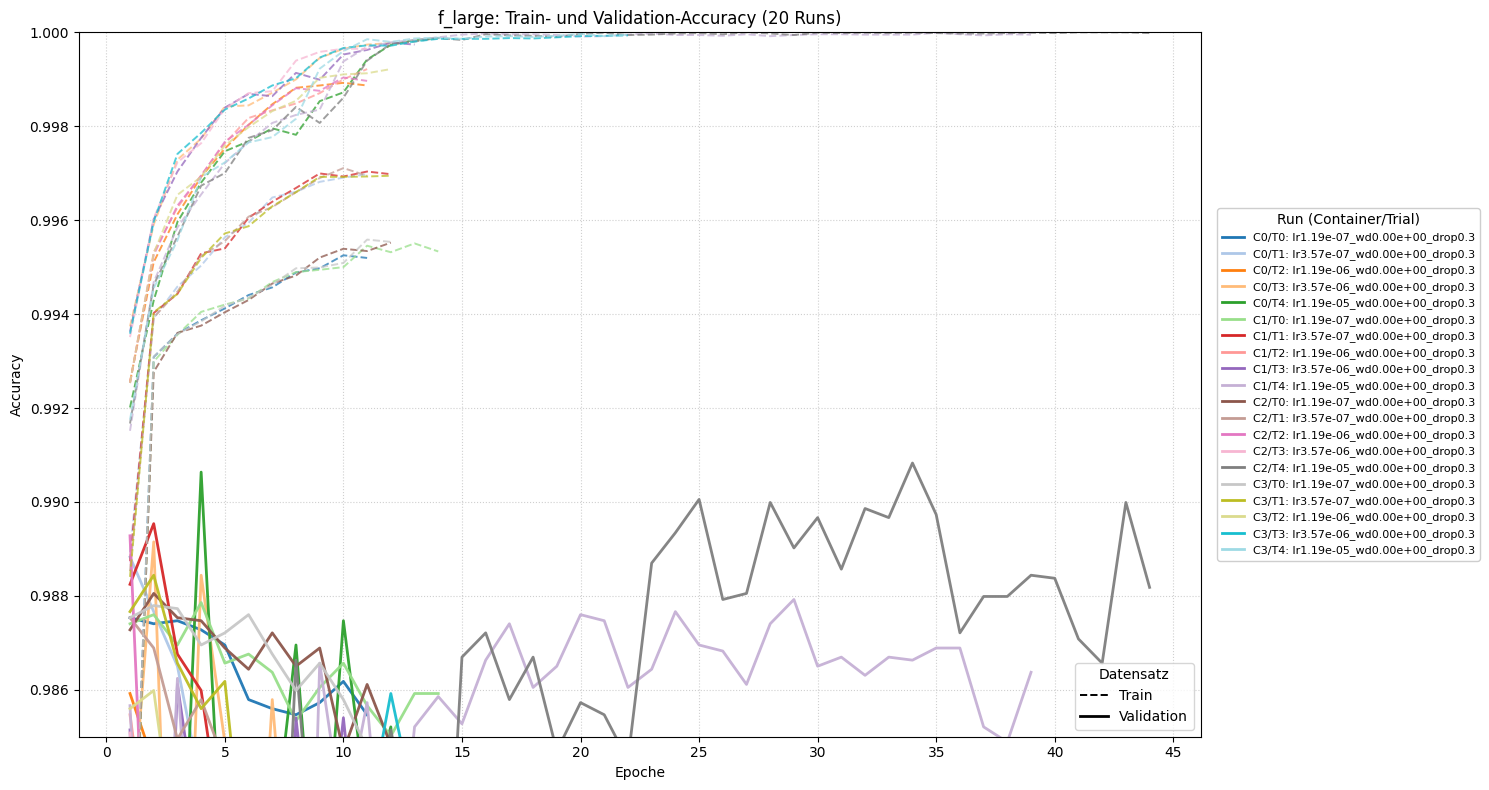

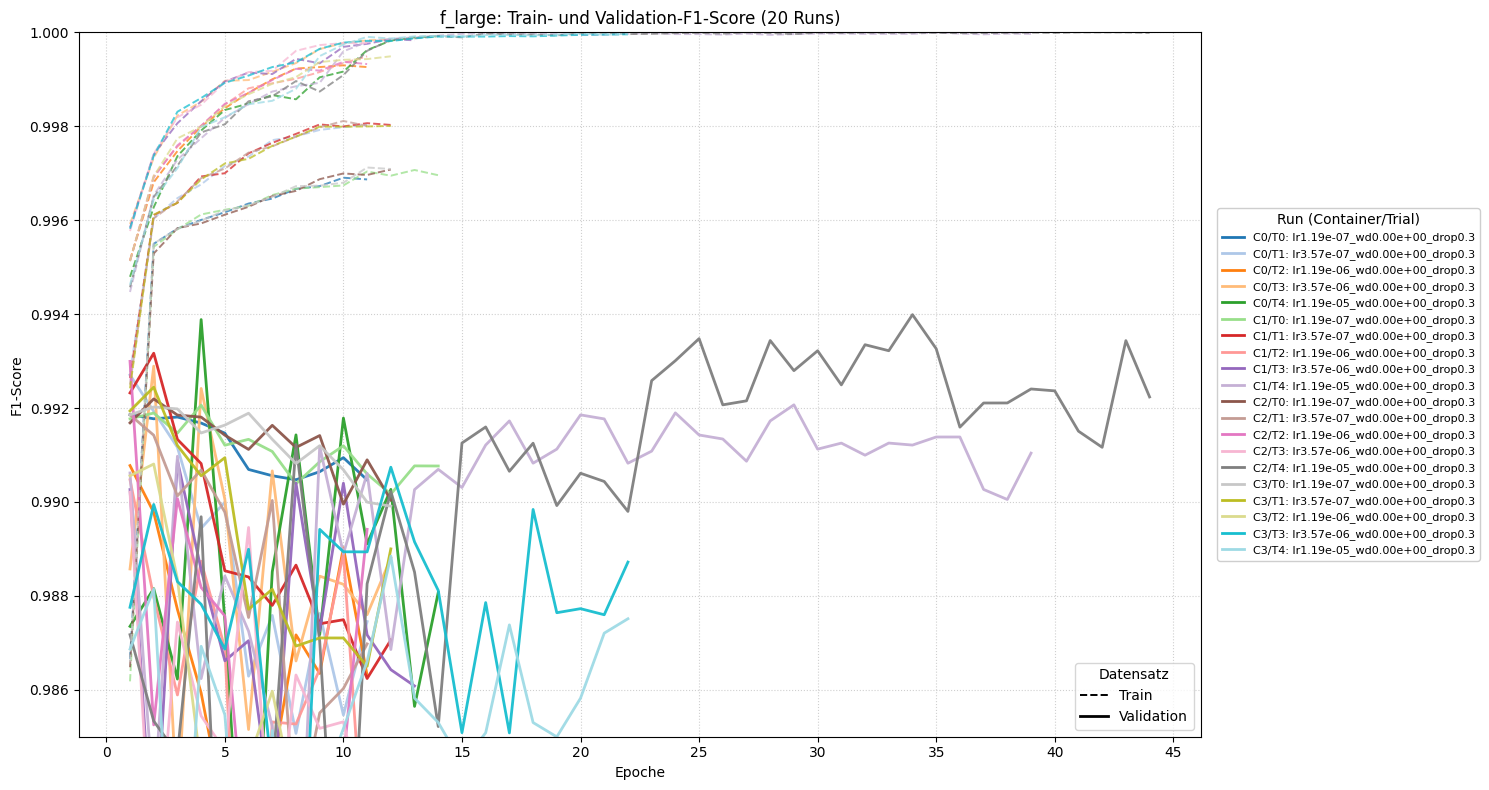

In [15]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


# TensorBoard-Runs des Finetunings mit und ohne Replay
BASE_DIRS = {
    "Replay": Path(
        "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/"
        "tensorboard_runs/tensorboard_runs_finetune_classifiers"
    ),
    "No Replay": Path(
        "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/"
        "tensorboard_runs/tensorboard_runs_finetune_classifiers_NOREPLAY"
    ),
}
CLASSIFIERS = ("f_small", "f_mid", "f_large")

# Optional: Path("finetune_classifier_plots") eintragen, um alle Plots zu speichern.
SAVE_DIR = None


def find_runs(base_dirs, classifier):
    """Findet alle Trials eines Klassifikators ueber alle Quellen hinweg."""
    if isinstance(base_dirs, (str, Path)):
        base_dirs = {"Run": Path(base_dirs)}

    container_pattern = f"RandomSearch_Finetune_{classifier}_Container*"
    runs = []
    for source_index, (source_label, base_dir) in enumerate(base_dirs.items()):
        for container_dir in base_dir.glob(container_pattern):
            match = re.search(r"Container(\d+)$", container_dir.name)
            if match is None:
                continue
            container = int(match.group(1))
            for run_dir in container_dir.glob("trial*"):
                trial_match = re.match(r"trial(\d+)_", run_dir.name)
                if trial_match is not None and run_dir.is_dir():
                    runs.append((source_index, source_label, container, int(trial_match.group(1)), run_dir))
    return sorted(runs, key=lambda item: (item[2], item[3], item[4].name, item[0]))


def read_scalar(metric_dir, tag):
    """Liest alle Scalar-Punkte ein und behält bei doppelten Steps den neuesten."""
    if not metric_dir.is_dir():
        raise FileNotFoundError(f"Metrikordner fehlt: {metric_dir}")

    accumulator = EventAccumulator(str(metric_dir), size_guidance={"scalars": 0})
    accumulator.Reload()
    scalar_tags = accumulator.Tags().get("scalars", [])
    if tag not in scalar_tags:
        raise KeyError(f"Tag {tag!r} fehlt in {metric_dir}; vorhanden: {scalar_tags}")

    # Bei fortgesetzten Runs kann ein Step mehrfach vorkommen. Der zeitlich neueste
    # Wert ist dann der gültige Wert.
    by_step = {}
    for event in accumulator.Scalars(tag):
        previous = by_step.get(event.step)
        if previous is None or event.wall_time >= previous[0]:
            by_step[event.step] = (event.wall_time, event.value)
    if not by_step:
        raise ValueError(f"Keine Werte für {tag!r} in {metric_dir}")

    steps = sorted(by_step)
    return steps, [by_step[step][1] for step in steps]


def run_details(run_name):
    """Entfernt die Trial-ID aus dem Run-Namen."""
    return run_name.split("_", 1)[1] if "_" in run_name else run_name


def run_key(container, trial, run_name):
    """Schluessel fuer gleiche Hyperparameter in Replay/No-Replay."""
    return (container, trial, run_details(run_name))


def short_run_label(container, trial, run_name):
    """Kompakte Legendenbeschriftung fuer die Konfiguration."""
    return f"C{container}/T{trial}: {run_details(run_name)}"


def plot_metric_for_classifier(base_dirs, classifier, metric, save_dir=None):
    """Erzeugt einen Train/Val-Plot mit sämtlichen Runs eines Klassifikators."""
    runs = find_runs(base_dirs, classifier)
    if not runs:
        raise FileNotFoundError(f"Keine Runs für {classifier} gefunden")

    tag = "Accuracy" if metric == "Accuracy" else "F1_score"
    config_keys = sorted({run_key(container, trial, run_dir.name) for _, _, container, trial, run_dir in runs})
    colors = plt.colormaps["tab20"].resampled(len(config_keys))
    color_by_config = {key: colors(index) for index, key in enumerate(config_keys)}
    source_markers = {"Replay": None, "No Replay": "o"}
    fig, ax = plt.subplots(figsize=(15, 8))
    for _, source_label, container, trial, run_dir in runs:
        config_key = run_key(container, trial, run_dir.name)
        color = color_by_config[config_key]
        marker = source_markers.get(source_label)

        train_steps, train_values = read_scalar(run_dir / f"{metric}_train", tag)
        val_steps, val_values = read_scalar(run_dir / f"{metric}_val", tag)

        train_markevery = max(1, len(train_steps) // 5)
        val_markevery = max(1, len(val_steps) // 5)

        ax.plot(
            train_steps,
            train_values,
            color=color,
            linestyle="--",
            linewidth=1.2,
            alpha=0.65,
            marker=marker,
            markevery=train_markevery,
            markersize=3.0,
            markerfacecolor="none",
            markeredgewidth=0.7,
        )
        ax.plot(
            val_steps,
            val_values,
            color=color,
            linestyle="-",
            linewidth=1.8,
            alpha=0.9,
            marker=marker,
            markevery=val_markevery,
            markersize=3.0,
            markerfacecolor="none",
            markeredgewidth=0.7,
        )

    run_handles = [
        Line2D([0], [0], color=color_by_config[key], linewidth=2, label=short_run_label(*key))
        for key in config_keys
    ]

    metric_label = "Accuracy" if metric == "Accuracy" else "F1-Score"
    ax.set_title(f"{classifier}: Train- und Validation-{metric_label} ({len(runs)} Runs)")
    ax.set_xlabel("Epoche")
    ax.set_ylabel(metric_label)
    ax.set_ylim(0.985, 1.0)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linestyle=":", alpha=0.6)

    style_handles = [
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.2, label="Train"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=1.8, label="Validation"),
        Line2D([0], [0], color="black", linestyle="-", marker="", linewidth=1.8, label="Replay"),
        Line2D([0], [0], color="black", linestyle="-", marker="o", markersize=3.0, markerfacecolor="none", linewidth=1.8, label="No Replay"),
    ]
    first_legend = ax.legend(handles=style_handles, loc="lower right", title="Kodierung")
    ax.add_artist(first_legend)
    ax.legend(
        handles=run_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        fontsize=8,
        title="Konfiguration (Container/Trial)",
        framealpha=0.95,
    )
    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        output_path = save_dir / f"{classifier}_{metric.lower()}_train_val.pdf"
        fig.savefig(output_path, bbox_inches="tight")
        print(f"Gespeichert: {output_path}")

    plt.show()
    return fig, ax


for source_label, base_dir in BASE_DIRS.items():
    if not base_dir.is_dir():
        raise FileNotFoundError(f"TensorBoard-Basisordner nicht gefunden ({source_label}): {base_dir}")

# Sechs Abbildungen: Accuracy und F1-Score für f_small, f_mid und f_large.
figures = {}
for classifier in CLASSIFIERS:
    for metric in ("Accuracy", "F1_score"):
        figures[(classifier, metric)] = plot_metric_for_classifier(
            BASE_DIRS, classifier, metric, save_dir=SAVE_DIR
        )
